# Flight Delay Prediction — T-60 Modeling

Bu notebook, ABD iç hat uçuşlarında **planlanan kalkıştan 60 dakika önce (T-60)** erişilebilir bilgilerle gecikme davranışını modellemek için hazırlanmıştır.

### Araştırma sorusu
Varış gecikmesini (`ArrDelay`) doğrudan tahmin etmek mi, yoksa gecikmeyi iki operasyonel bileşene ayırmak mı daha başarılıdır?

- **M1 — Departure component:** `DepDelay`
- **M2 — In-flight / gate-to-gate component:** `Elapsed_Time_Deviation = ActualElapsedTime - CRSElapsedTime`
- **M3 — Direct arrival model:** `ArrDelay`

Matematiksel ilişki:

`ArrDelay = DepDelay + Elapsed_Time_Deviation`

### Zaman ayrımı
- **Train:** Temmuz 2025 – Mart 2026
- **Validation:** Nisan – Mayıs 2026
- **Final holdout test:** Haziran 2026

Model seçimleri yalnızca validation dönemi üzerinde yapılmış, Haziran 2026 verisi final değerlendirmeye kadar kullanılmamıştır.


In [ ]:
import os
import gc
import time
import zipfile
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from timezonefinder import TimezoneFinder
from feature_engine.encoding import CountFrequencyEncoder

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


## Raw Data Loading Strategy / Ham Veri Okuma Stratejisi

**TR:** BTS uçuş verileri aylık ZIP dosyaları halinde saklanmaktadır. Büyük CSV dosyalarını diske çıkarmak yerine ZIP dosyaları doğrudan Python üzerinden okunacaktır. Böylece disk alanından tasarruf edilir ve ham veri klasörü daha düzenli tutulur.

**EN:** BTS flight data is stored as monthly ZIP archives. Instead of extracting the large CSV files to disk, the data will be read directly from the ZIP archives using Python. This reduces disk usage and keeps the raw data directory clean.

### July 2025 ZIP File / Temmuz 2025 ZIP Dosyası

**TR:** İlk olarak Temmuz 2025 verisi üzerinde veri okuma süreci test edilmektedir. Başarılı olduğunda aynı işlem diğer aylara uygulanacaktır.

**EN:** The data loading process is first tested using the July 2025 dataset. Once validated, the same process will be applied to the remaining months.

In [ ]:
zip_path = "../data/raw/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_7.zip"

### ZIP File Inspection / ZIP Dosyası Kontrolü

**TR:** ZIP arşivinin içeriği kontrol edilerek arşiv içerisindeki CSV dosyasının gerçek adı belirlenmektedir. Böylece dosya adı tahmin edilmeden doğru dosya doğrudan okunabilir.

**EN:** The contents of the ZIP archive are inspected to identify the exact CSV filename. This avoids manually guessing the filename and allows the correct file to be read directly.

In [ ]:
with zipfile.ZipFile(zip_path, "r") as z:
    print(z.namelist())

### Selected Columns / Seçilen Kolonlar

**TR:** Tüm 110 değişkeni kullanmak yerine yalnızca modelleme, hedef değişken oluşturma, filtreleme ve EDA için gerekli olan seçilmiş kolonlar okunacaktır. Bu yaklaşım bellek kullanımını azaltır ve veri işleme sürecini daha verimli hale getirir.

**EN:** Instead of loading all 110 variables, only the columns required for modeling, target construction, filtering, and EDA will be read. This reduces memory usage and makes the data processing pipeline more efficient.

In [9]:
selected_columns = [
    "FlightDate",
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "DepDelay",
    "ActualElapsedTime",
    "ArrDelay",
    "Cancelled",
    "Diverted",
    "TaxiOut",
    "AirTime",
    "TaxiIn",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

### Reading the CSV Directly from ZIP / CSV Dosyasını ZIP İçinden Doğrudan Okuma

**TR:** ZIP arşivinin içindeki CSV dosyası diske çıkarılmadan doğrudan Pandas ile okunmaktadır. Yalnızca seçilen kolonlar belleğe alınmaktadır.

**EN:** The CSV file inside the ZIP archive is read directly with Pandas without extracting it to disk. Only the selected columns are loaded into memory.

In [ ]:
with zipfile.ZipFile(zip_path, "r") as z:
    csv_file = [name for name in z.namelist() if name.endswith(".csv")][0]

    with z.open(csv_file) as f:
        july_df = pd.read_csv(f, usecols=selected_columns)

In [ ]:
july_df.shape

In [ ]:
july_df.memory_usage(deep=True).sum() / 1024**2

### Daily Random Sampling / Günlük Rastgele Örnekleme

**TR:** Yıl boyunca tüm tarihlerin temsil edilmesini sağlamak için veri setinin tamamından tek seferde örnek almak yerine her gün içerisindeki uçuşların %15'i rastgele seçilmektedir. `random_state=11` kullanılarak aynı örneklemin tekrar üretilebilmesi sağlanmaktadır.

**EN:** To ensure that all dates throughout the year remain represented, 15% of flights are randomly sampled within each day instead of sampling from the entire dataset at once. `random_state=11` is used to make the sampling process reproducible.

In [ ]:
july_sample = (
    july_df
    .groupby("FlightDate", group_keys=False)
    .sample(frac=0.15, random_state=11)
    .reset_index(drop=True)
)

In [ ]:
july_sample.shape

In [ ]:
len(july_sample) / len(july_df)

In [ ]:
july_df["FlightDate"].nunique(), july_sample["FlightDate"].nunique()

### Saving the Sampled Data / Örneklenmiş Verinin Kaydedilmesi

**TR:** Günlük %15 rastgele örnekleme sonrasında elde edilen veri Parquet formatında kaydedilmektedir. Parquet, CSV'ye göre daha verimli depolama sağlar ve veri tiplerini koruyarak daha hızlı okuma/yazma işlemleri sunar.

**EN:** After applying daily 15% random sampling, the resulting dataset is saved in Parquet format. Parquet provides more efficient storage than CSV and preserves data types while enabling faster read/write operations.

In [ ]:
july_sample.to_parquet(
    "../data/interim/flights_2025_07_sample.parquet",
    index=False
)

In [ ]:
os.path.getsize("../data/interim/flights_2025_07_sample.parquet") / 1024**2

### Monthly Processing Setup / Aylık İşleme Hazırlığı

**TR:** Temmuz 2025 üzerinde doğrulanan veri hazırlama süreci diğer aylara uygulanacaktır. Her ay ZIP dosyasından doğrudan okunacak, yalnızca seçilen 23 kolon alınacak ve her günün uçuşlarından %15 rastgele örnek seçilecektir.

**EN:** The data preparation process validated on July 2025 will be applied to the remaining months. Each monthly ZIP file will be read directly, only the selected 23 columns will be loaded, and 15% of flights will be randomly sampled within each day.

In [ ]:
months_to_process = [
    (2025, 7),
    (2025, 8),
    (2025, 9),
    (2025, 10),
    (2025, 11),
    (2025, 12),
    (2026, 1),
    (2026, 2),
    (2026, 3),
    (2026, 4),
    (2026, 5)
]

In [ ]:
for year, month in months_to_process:
    zip_path = f"../data/raw/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{year}_{month}.zip"

    with zipfile.ZipFile(zip_path, "r") as z:
        csv_file = [name for name in z.namelist() if name.endswith(".csv")][0]

        with z.open(csv_file) as f:
            month_df = pd.read_csv(f, usecols=selected_columns)

    month_sample = (
        month_df
        .groupby("FlightDate", group_keys=False)
        .sample(frac=0.15, random_state=11)
        .reset_index(drop=True)
    )

    month_sample.to_parquet(
        f"../data/interim/flights_{year}_{month:02d}_sample.parquet",
        index=False
    )
    print(f"{year}-{month:02d} -> {len(month_sample)} rows")

In [ ]:
os.listdir("../data/interim")

### Automatic Parquet File Discovery / Parquet Dosyalarının Otomatik Bulunması

**TR:** `data/interim/` klasöründeki örneklenmiş Parquet dosyaları otomatik olarak bulunur. Böylece yeni bir aylık dosya eklendiğinde dosya listesini manuel olarak güncellemek gerekmez.

**EN:** The sampled Parquet files in the `data/interim/` directory are discovered automatically. This avoids manually updating the file list when new monthly files are added.

In [10]:
parquet_files = [
    file for file in os.listdir("../data/interim")
    if file.endswith("_sample.parquet")
]

parquet_files

['flights_2025_07_sample.parquet',
 'flights_2025_08_sample.parquet',
 'flights_2025_09_sample.parquet',
 'flights_2025_10_sample.parquet',
 'flights_2025_11_sample.parquet',
 'flights_2025_12_sample.parquet',
 'flights_2026_01_sample.parquet',
 'flights_2026_02_sample.parquet',
 'flights_2026_03_sample.parquet',
 'flights_2026_04_sample.parquet',
 'flights_2026_05_sample.parquet']

In [11]:
df_ = pd.concat(
    [
        pd.read_parquet(f"../data/interim/{file}")
        for file in parquet_files
    ],
    ignore_index=True
)

In [12]:
df = df_.copy()

In [13]:

def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### Tail #####################")
    print(dataframe.tail(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1], numeric_only=True).T)


In [ ]:
check_df(df,head=5)

In [ ]:
df['FlightDate'].nunique()

In [ ]:
df["FlightDate"].min(), df["FlightDate"].max()

In [ ]:
df.groupby("Month").size()

### Final Holdout Set — Haziran 2026

Haziran 2026 verisi örneklenmeden ayrı bir Parquet dosyasına kaydedilmiştir. Bu dönem model seçimi ve hiperparametre kararlarında kullanılmayacak, yalnızca final test aşamasında açılacaktır.


In [14]:
june_zip_path = "../data/raw/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2026_6.zip"


In [15]:
with zipfile.ZipFile(june_zip_path, "r") as z:
    june_csv_file = [name for name in z.namelist() if name.endswith(".csv")][0]

    with z.open(june_csv_file) as f:
        june_test_df = pd.read_csv(f, usecols=selected_columns)

In [16]:
june_test_df.to_parquet(
    "../data/interim/flights_2026_06_full.parquet",
    index=False
)

In [ ]:
june_test_df.shape

In [ ]:
june_test_df["FlightDate"].min(), june_test_df["FlightDate"].max()

## Data Understanding / Veri Setini Anlama

**TR:** Bu aşamada birleştirilmiş geliştirme veri setinin yapısı, değişken tipleri, eksik değerleri ve model hedeflerini etkileyebilecek özel durumlar incelenmektedir. Modelleme öncesinde veri kalitesinin ve hedef değişkenlerin kullanılabilirliğinin anlaşılması amaçlanmaktadır.

**EN:** At this stage, the structure, data types, missing values, and special cases that may affect the modeling targets are examined. The objective is to understand data quality and target availability before preprocessing and modeling.

In [ ]:
df.info()

In [17]:
def missing_values_table(dataframe, na_name=False):
    """Eksik verilerin sayısını ve oransal dağılımını tablo olarak verir."""
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns




In [ ]:
missing_values_table(df)

In [ ]:
df["Cancelled"].value_counts()

In [ ]:
df["Diverted"].value_counts()

### Defining the Modeling Population / Modelleme Evreninin Tanımlanması

**TR:** İptal edilen (`Cancelled = 1`) ve başka bir havalimanına yönlendirilen (`Diverted = 1`) uçuşlar, bu projede tanımlanan normal tamamlanmış uçuş senaryosunun dışında kaldığı için modelleme veri setinden çıkarılacaktır. Ham çalışma verisi korunacak, yalnızca modelleme için ayrı bir `model_df` oluşturulacaktır. Böylece veri kaybı yerine hedef popülasyon daha doğru şekilde tanımlanmış olur.

**EN:** Cancelled flights (`Cancelled = 1`) and diverted flights (`Diverted = 1`) fall outside the normal completed-flight scenario defined for this project and will therefore be excluded from the modeling dataset. The original working data will be preserved, while a separate `model_df` will be created for modeling. This represents a clearer definition of the target population rather than simple data loss.

In [18]:
model_df = df[(df["Cancelled"] == 0) & (df["Diverted"] == 0)].copy()

In [ ]:
model_df.shape

In [19]:
drop_columns =["Cancelled", "Diverted"]

In [20]:
model_df = model_df.drop(drop_columns, axis=1)

In [ ]:
model_df.info()

In [ ]:
missing_values_table(model_df)

In [ ]:
model_df[model_df['CRSElapsedTime'].isnull()]

In [21]:
model_df = model_df.drop(model_df[model_df['CRSElapsedTime'].isnull()].index, axis=0)


In [ ]:
missing_values_table(model_df)

In [22]:
delay_cols = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

In [ ]:
model_df[
    (model_df["ArrDelay"] >= 15) &
    (model_df[delay_cols].isna().all(axis=1))
]

### Delay Reason Missingness Analysis / Gecikme Nedeni Eksiklik Analizi

**TR:**
`CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay` ve `LateAircraftDelay` değişkenlerinde yüksek oranda `NaN` değer gözlemlenmiştir. İlk bakışta bu durum ciddi bir eksik veri problemi gibi görünse de yapılan kontroller sonucunda bu boşlukların rastgele oluşmadığı görülmüştür.

Gecikme nedeni kolonlarından en az biri dolu olan uçuşlar incelendiğinde minimum `ArrDelay` değerinin **15 dakika** olduğu görülmüştür. Buna karşılık, gecikme nedeni kolonlarının tamamı boş olan uçuşlarda maksimum `ArrDelay` değeri **14 dakika** olarak bulunmuştur.

Daha sonra veri kalite kontrolü amacıyla `ArrDelay >= 15` olan uçuşlarda gecikme nedeni kolonları ayrıca incelenmiştir. Bu grupta gecikme nedeni kolonlarının tamamının boş olduğu herhangi bir gözlem bulunmamıştır.

Ek olarak daha sıkı bir kontrol yapılarak, `ArrDelay >= 15` olan uçuşlarda gecikme nedeni kolonlarından herhangi birinin eksik olup olmadığı kontrol edilmiştir. Bu kontrolde de **0 gözlem** bulunmuştur. Böylece 15 dakika ve üzeri varış gecikmesine sahip uçuşlarda `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay` ve `LateAircraftDelay` değişkenlerinin tamamının eksiksiz şekilde raporlandığı doğrulanmıştır.

Bu bulgulara göre gecikme nedeni değişkenlerindeki yüksek `NaN` oranı rastgele veya gerçek bir veri eksikliği olarak değerlendirilmemektedir. Bunun yerine, `ArrDelay` değeri 15 dakikanın altında olan uçuşlarda gecikme nedeni kırılımlarının raporlanmamasından kaynaklanan **yapısal eksiklik (structural missingness)** olarak yorumlanmıştır.

Bu değişkenler uçuş tamamlandıktan sonra oluşan bilgiler içerdiği için model girdisi olarak kullanılmayacaktır. Ancak EDA aşamasında gecikmelerin hangi operasyonel nedenlerden kaynaklandığını incelemek amacıyla tutulacaktır.

---

**EN:**
A high proportion of `NaN` values was observed in `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, and `LateAircraftDelay`. Although this initially appeared to be a major missing-data problem, further analysis showed that the missing values do not occur randomly.

Among flights where at least one delay-reason variable was reported, the minimum observed `ArrDelay` was **15 minutes**. In contrast, among flights where all delay-reason variables were missing, the maximum observed `ArrDelay` was **14 minutes**.

As an additional data-quality check, flights with `ArrDelay >= 15` were examined separately. No observations were found where all delay-reason variables were missing.

A stricter validation was then performed to determine whether any individual delay-reason variable was missing among flights with `ArrDelay >= 15`. This check also returned **0 observations**. Therefore, for flights with arrival delays of 15 minutes or more, all five delay-reason variables — `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, and `LateAircraftDelay` — were confirmed to be fully reported.

Based on these findings, the high proportion of `NaN` values in the delay-reason variables is not interpreted as random or ordinary missing data. Instead, it is considered **structural missingness** caused by the reporting structure for flights with `ArrDelay` values below 15 minutes.

These variables will not be used as model features because they contain information generated after the flight has occurred. However, they will be retained for EDA in order to analyze the operational causes of flight delays.

In [25]:

def grab_col_names(dataframe, cat_th=12, car_th=400):
    """
    Veri setindeki kategorik, numerik ve kardinal değişken isimlerini verir.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        İncelenmek istenen dataframe.
    cat_th : int, optional (default=10)
        Nümeric fakat kategorik sayılabilecek değişkenler için eşik değer.
    car_th : int, optional (default=20)
        Kategorik fakat kardinal (çok fazla benzersiz değere sahip) değişkenler için eşik değer.

    Returns
    -------
    cat_cols : list
        Kategorik değişken isimleri.
    num_cols : list
        Nümeric değişken isimleri.
    cat_but_car : list
        Kategorik görünümlü kardinal değişken isimleri.
    """
    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [
        col for col in dataframe.columns
        if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"
    ]
    cat_but_car = [
        col for col in dataframe.columns
        if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"
    ]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car

In [26]:
cat_cols, num_cols, cat_but_car = grab_col_names(model_df)

Observations: 945159
Variables: 21
cat_cols: 2
num_cols: 19
cat_but_car: 0
num_but_cat: 2


In [27]:
model_df["FlightDate"] = pd.to_datetime(model_df["FlightDate"])
model_df["Reporting_Airline"] = model_df["Reporting_Airline"].astype("object")
model_df["Origin"] = model_df["Origin"].astype("object")
model_df["Dest"] = model_df["Dest"].astype("object")

In [28]:
cat_cols, num_cols, cat_but_car = grab_col_names(model_df)

Observations: 945159
Variables: 21
cat_cols: 5
num_cols: 16
cat_but_car: 0
num_but_cat: 2


In [29]:
model_df["Elapsed_Time_Deviation"] = model_df["ActualElapsedTime"] - model_df["CRSElapsedTime"]

In [30]:
cat_cols, num_cols, cat_but_car = grab_col_names(model_df)

Observations: 945159
Variables: 22
cat_cols: 5
num_cols: 17
cat_but_car: 0
num_but_cat: 2


In [31]:
np.allclose(
    model_df["DepDelay"] + model_df["Elapsed_Time_Deviation"],
    model_df["ArrDelay"]
)

False

In [ ]:
model_df[(model_df["DepDelay"] + model_df["Elapsed_Time_Deviation"] != model_df["ArrDelay"])]

### Target Consistency Check / Hedef Değişken Tutarlılık Kontrolü

**TR:**
Projenin üç hedef değişkeni arasındaki matematiksel ilişki aşağıdaki şekilde tanımlanmıştır:

`ArrDelay = DepDelay + Elapsed_Time_Deviation`

Burada:

- `DepDelay`: Planlanan kalkış saatine göre gerçekleşen kalkış sapması
- `Elapsed_Time_Deviation`: Gerçek gate-to-gate uçuş süresi ile planlanan gate-to-gate uçuş süresi arasındaki fark
- `ArrDelay`: Planlanan varış saatine göre gerçekleşen varış sapması

Toplam **945.159** gözlem üzerinde yapılan tutarlılık kontrolünde, **945.144 gözlemde eşitliğin sağlandığı**, yalnızca **15 gözlemde eşitliğin sağlanmadığı** görülmüştür.

Bu 15 gözlemdeki farkların yalnızca küçük yuvarlama farkları olmadığı, bazı kayıtlarda onlarca dakikalık tutarsızlık bulunduğu gözlemlenmiştir. Bu nedenle söz konusu kayıtlar veri tutarlılığı açısından anomalik gözlemler olarak değerlendirilmiştir.

Bu proje, doğrudan `ArrDelay` tahmini ile `DepDelay + Elapsed_Time_Deviation` bileşenlerinin ayrı ayrı tahmin edilip birleştirilmesini karşılaştırdığı için, hedefler arasındaki matematiksel tutarlılığın korunması önemlidir. Bu nedenle söz konusu **15 tutarsız gözlem modelleme veri setinden çıkarılacaktır**.

---

**EN:**
The mathematical relationship among the three target variables used in this project is defined as:

`ArrDelay = DepDelay + Elapsed_Time_Deviation`

where:

- `DepDelay`: Deviation from the scheduled departure time
- `Elapsed_Time_Deviation`: Difference between actual and scheduled gate-to-gate elapsed time
- `ArrDelay`: Deviation from the scheduled arrival time

A consistency check was performed on a total of **945,159 observations**. The relationship held for **945,144 observations**, while only **15 observations** violated the expected equality.

The differences observed in these 15 records were not limited to minor rounding errors; some records showed inconsistencies of several tens of minutes. Therefore, these observations were treated as anomalous records from a data-consistency perspective.

Since this project compares direct `ArrDelay` prediction with an indirect approach based on separately predicting `DepDelay` and `Elapsed_Time_Deviation` and combining them, maintaining mathematical consistency among the target variables is important. Therefore, these **15 inconsistent observations will be excluded from the modeling dataset**.

In [32]:
model_df = model_df.drop(
    model_df[
        model_df["DepDelay"] + model_df["Elapsed_Time_Deviation"] != model_df["ArrDelay"]
    ].index,
    axis=0
)

In [ ]:
model_df.shape

In [ ]:
model_df[["DepDelay", "Elapsed_Time_Deviation", "ArrDelay"]].describe().T

In [33]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99, 0.995]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show()


In [ ]:
for col in num_cols:
    num_summary(model_df, col, plot=True)

In [34]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(dropna=False),
                        "Ratio": 100 * dataframe[col_name].value_counts(dropna=False) / len(dataframe)}))
    print("##########################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show()


In [ ]:
model_df.groupby("Reporting_Airline")["ArrDelay"].mean()

In [ ]:
model_df.groupby("Reporting_Airline")["ArrDelay"].median()

In [ ]:
(model_df["ArrDelay"] >= 15).groupby(model_df["Reporting_Airline"]).mean().sort_values(ascending=False) * 100

In [35]:
airline_delay_sum = model_df.groupby("Reporting_Airline")[delay_cols].sum().copy()

In [36]:
airline_delay_sum["TotalDelayReason"] = airline_delay_sum[delay_cols].sum(axis=1)

In [37]:
for col in delay_cols:
    airline_delay_sum[f"{col}_Pct"] = (
        airline_delay_sum[col] / airline_delay_sum["TotalDelayReason"] * 100
    )

In [38]:
airline_delay_sum[
    [
        "CarrierDelay_Pct",
        "WeatherDelay_Pct",
        "NASDelay_Pct",
        "SecurityDelay_Pct",
        "LateAircraftDelay_Pct",
        "TotalDelayReason"
    ]
].sort_values("TotalDelayReason", ascending = False)

,CarrierDelay_Pct,WeatherDelay_Pct,NASDelay_Pct,SecurityDelay_Pct,LateAircraftDelay_Pct,TotalDelayReason
Reporting_Airline,,,,,,
AA,34.084305,5.403451,14.028662,0.148694,46.334888,2785590.0
WN,27.508527,2.389861,18.491377,0.302998,51.307238,2268333.0
OO,47.772011,13.638343,17.213919,0.098914,21.276814,2138229.0
DL,44.266018,4.077589,21.347981,0.043835,30.264576,1799936.0
UA,25.877342,4.636217,33.680544,0.009041,35.796856,1637046.0
OH,27.612309,8.995175,12.606959,0.159911,50.625647,746667.0
YX,23.687678,5.519306,31.868436,0.065195,38.859385,736252.0
B6,27.620508,2.271556,26.045201,0.160588,43.902147,634543.0
F9,26.864792,2.700526,18.671607,0.000000,51.763075,605845.0


In [39]:
model_df.groupby("Month").agg({
    "ArrDelay": ["mean", "median"]
})

ArrDelay       
            mean median
Month                  
1       6.334524   -7.0
2       4.430963   -8.0
3      10.376738   -6.0
4       4.860107   -7.0
5       5.923290   -7.0
7      17.296100   -3.0
8       9.390536   -5.0
9       2.407084   -8.0
10      5.676903   -6.0
11      6.246593   -7.0
12     13.036077   -3.0

In [ ]:
model_df.groupby("Month").size().sort_values(ascending = False)

In [40]:
month_delay_sum = model_df.groupby("Month")[delay_cols].sum().copy()

In [41]:
month_delay_sum["TotalDelayReason"] = month_delay_sum[delay_cols].sum(axis=1)

In [42]:
for col in delay_cols:
    month_delay_sum[f"{col}_Pct"] = (
        month_delay_sum[col] / month_delay_sum["TotalDelayReason"] * 100
    )

In [43]:
month_delay_sum[
    [
        "CarrierDelay_Pct",
        "WeatherDelay_Pct",
        "NASDelay_Pct",
        "SecurityDelay_Pct",
        "LateAircraftDelay_Pct",
        "TotalDelayReason"
    ]
].sort_values("TotalDelayReason", ascending = False)

,CarrierDelay_Pct,WeatherDelay_Pct,NASDelay_Pct,SecurityDelay_Pct,LateAircraftDelay_Pct,TotalDelayReason
Month,,,,,,
7,30.666681,7.378953,20.668712,0.140874,41.144780,2161499.0
12,33.610429,6.221377,19.238133,0.167232,40.762829,1724554.0
3,33.616677,6.216160,21.282522,0.254944,38.629696,1673702.0
8,33.165609,6.720525,18.960939,0.120926,41.032001,1484378.0
5,32.644742,6.023897,20.844555,0.142913,40.343894,1284700.0
11,30.288823,5.054234,26.549132,0.096435,38.011376,1246440.0
1,36.978379,9.052522,17.943121,0.131485,35.894492,1212303.0
4,33.185707,4.269254,20.770651,0.096340,41.678048,1197844.0
10,33.180777,3.579847,23.457133,0.118445,39.663798,1185358.0


In [44]:
model_df["Route"] = model_df["Origin"]+ "_" + model_df["Dest"]

In [ ]:
model_df["Route"].nunique()

In [ ]:
model_df.groupby("Route").size().sort_values(ascending = False)

In [45]:
route_counts = model_df.groupby("Route").size()

In [46]:
valid_routes = route_counts[route_counts > 1000].index

In [47]:
route_delay_sum = (
    model_df[model_df["Route"].isin(valid_routes)]
    .groupby("Route")[delay_cols]
    .sum()
)

In [48]:
route_delay_sum["TotalDelayReason"] = route_delay_sum[delay_cols].sum(axis=1)

In [49]:
for col in delay_cols:
    route_delay_sum[f"{col}_Pct"] = (
        route_delay_sum[col] / route_delay_sum["TotalDelayReason"] * 100
    )

In [50]:
route_delay_sum[
    [
        "CarrierDelay_Pct",
        "WeatherDelay_Pct",
        "NASDelay_Pct",
        "SecurityDelay_Pct",
        "LateAircraftDelay_Pct",
        "TotalDelayReason"
    ]
].sort_values("TotalDelayReason", ascending = False)

,CarrierDelay_Pct,WeatherDelay_Pct,NASDelay_Pct,SecurityDelay_Pct,LateAircraftDelay_Pct,TotalDelayReason
Route,,,,,,
LGA_ORD,19.087090,7.932594,36.838380,0.000000,36.141937,43794.0
ORD_LGA,19.763886,3.669334,37.873913,0.000000,38.692866,37609.0
LAX_JFK,40.062033,0.000000,20.648183,0.079124,39.210660,31596.0
DCA_BOS,20.352191,3.710825,32.064906,0.000000,43.872078,29643.0
LAX_SFO,21.017260,1.491003,48.788101,0.000000,28.703636,27230.0
MCO_ATL,38.909603,4.614975,20.601887,0.068483,35.805053,26284.0
BOS_DCA,25.882353,2.316927,30.444178,0.108043,41.248499,24990.0
SFO_LAX,24.596188,1.307581,17.088283,0.000000,57.007948,23402.0
ATL_LGA,26.992714,2.927446,40.465076,0.061079,29.553684,22921.0


In [51]:
def target_summary_with_cat(dataframe, target, categorical_col):
    print(categorical_col)

    summary_df = pd.DataFrame({
        "TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean(),
        "TARGET_MEDIAN": dataframe.groupby(categorical_col)[target].median(),
        "Count": dataframe[categorical_col].value_counts(),
        "Ratio": 100 * dataframe[categorical_col].value_counts() / len(dataframe)
    })

    print(summary_df, end="\n\n\n")

In [55]:
Elapsed_Time_Deviation_corr = model_df[num_cols ].corr()["Elapsed_Time_Deviation"].sort_values(ascending=False)


In [56]:
Elapsed_Time_Deviation_corr

Elapsed_Time_Deviation    1.000000
TaxiOut                   0.596301
NASDelay                  0.425207
TaxiIn                    0.372931
ArrDelay                  0.277579
ActualElapsedTime         0.121080
DepDelay                  0.032243
CRSArrTime                0.024131
WeatherDelay              0.017911
CRSDepTime                0.010248
AirTime                  -0.004841
SecurityDelay            -0.008525
FlightDate               -0.044665
Distance                 -0.067825
CRSElapsedTime           -0.081516
CarrierDelay             -0.092815
LateAircraftDelay        -0.161763
Name: Elapsed_Time_Deviation, dtype: float64

### Target Correlation Findings / Hedef Değişken Korelasyon Bulguları

**TR:**
`Elapsed_Time_Deviation` (gerçek gate-to-gate uçuş süresi ile planlanan gate-to-gate süre arasındaki sapma) ile diğer sayısal değişkenler arasındaki korelasyonlar incelenmiştir.

En dikkat çekici ilişkiler:

- `TaxiOut` ile yaklaşık **0.60**
- `NASDelay` ile yaklaşık **0.43**
- `TaxiIn` ile yaklaşık **0.37**
- `ArrDelay` ile yaklaşık **0.28**
- `DepDelay` ile yalnızca yaklaşık **0.03**

Bu sonuç, `Elapsed_Time_Deviation` ile `DepDelay` arasında oldukça düşük bir doğrusal ilişki olduğunu göstermektedir. Buna karşılık uçuş süresi sapması özellikle `TaxiOut` ve `TaxiIn` gibi yer operasyonu değişkenleriyle daha güçlü ilişki göstermektedir.

Bu bulgu, kalkış gecikmesi ile uçuş süresi sapmasının toplam varış gecikmesinin farklı operasyonel bileşenlerini temsil ettiğini desteklemektedir.

`TaxiOut`, `TaxiIn` ve `NASDelay` gibi değişkenler uçuş sonrasında oluştuğu için yüksek korelasyonlarına rağmen model girdisi olarak kullanılmayacaktır. Bu değişkenler yalnızca EDA ve operasyonel yorumlama amacıyla değerlendirilecektir.

---

**EN:**
Correlations between `Elapsed_Time_Deviation` and other numerical variables were examined.

The most notable relationships were:

- approximately **0.60** with `TaxiOut`
- approximately **0.43** with `NASDelay`
- approximately **0.37** with `TaxiIn`
- approximately **0.28** with `ArrDelay`
- only approximately **0.03** with `DepDelay`

These results indicate that `Elapsed_Time_Deviation` has very little linear relationship with departure delay, while it is more strongly associated with ground-operation variables such as taxi-out and taxi-in times.

This supports the idea that departure delay and elapsed-time deviation represent different operational components of total arrival delay.

Although variables such as `TaxiOut`, `TaxiIn`, and `NASDelay` show meaningful correlations, they will not be used as model features because they are not available at the pre-flight prediction time. They will be retained only for EDA and operational interpretation.

In [57]:
DepDelay_corr = (
    model_df[num_cols]
    .corr()["DepDelay"]
    .sort_values(ascending=False)
)

In [58]:
DepDelay_corr

DepDelay                  1.000000
ArrDelay                  0.969153
CarrierDelay              0.669009
LateAircraftDelay         0.544659
WeatherDelay              0.298562
NASDelay                  0.127229
CRSDepTime                0.109329
CRSArrTime                0.093942
TaxiOut                   0.060503
Elapsed_Time_Deviation    0.032243
ActualElapsedTime         0.014699
TaxiIn                    0.013483
SecurityDelay             0.012005
CRSElapsedTime            0.008211
AirTime                   0.004585
Distance                  0.004078
FlightDate               -0.015759
Name: DepDelay, dtype: float64

### Departure Delay Correlation Findings / Kalkış Gecikmesi Korelasyon Bulguları

**TR:**
`DepDelay` (planlanan kalkış saatine göre gerçekleşen sapma) ile diğer sayısal değişkenler arasındaki korelasyonlar incelenmiştir.

En dikkat çekici ilişkiler:

- `ArrDelay` ile yaklaşık **0.97**
- `CarrierDelay` ile yaklaşık **0.67**
- `LateAircraftDelay` ile yaklaşık **0.54**
- `WeatherDelay` ile yaklaşık **0.30**
- `Elapsed_Time_Deviation` ile yalnızca yaklaşık **0.03**

`DepDelay` ile `ArrDelay` arasındaki çok güçlü pozitif ilişki, varış sapmasının büyük bölümünün kalkışta oluşan gecikmeyle ilişkili olduğunu göstermektedir.

Buna karşılık `DepDelay` ile `Elapsed_Time_Deviation` arasındaki çok düşük korelasyon, kalkış sapması ile uçuşun gate-to-gate süresindeki sapmanın farklı operasyonel süreçleri temsil ettiğini desteklemektedir.

`CarrierDelay`, `LateAircraftDelay` ve `WeatherDelay` gibi gecikme nedeni değişkenleri kalkış gecikmesiyle anlamlı ilişkiler göstermesine rağmen uçuş tamamlandıktan sonra raporlandıkları için model girdisi olarak kullanılmayacaktır. Bu değişkenler yalnızca EDA ve operasyonel yorumlama amacıyla değerlendirilecektir.

In [59]:
ArrDelay_corr = (
    model_df[num_cols]
    .corr()["ArrDelay"]
    .sort_values(ascending=False)
)


In [60]:
ArrDelay_corr

ArrDelay                  1.000000
DepDelay                  0.969153
CarrierDelay              0.665806
LateAircraftDelay         0.523481
WeatherDelay              0.309913
Elapsed_Time_Deviation    0.277579
NASDelay                  0.222022
TaxiOut                   0.205196
CRSDepTime                0.107615
TaxiIn                    0.104920
CRSArrTime                0.096248
ActualElapsedTime         0.043986
SecurityDelay             0.010470
AirTime                   0.003214
CRSElapsedTime           -0.012209
Distance                 -0.012806
FlightDate               -0.026161
Name: ArrDelay, dtype: float64

### Arrival Delay Correlation Findings / Varış Gecikmesi Korelasyon Bulguları

**TR:**
`ArrDelay` (planlanan varış saatine göre gerçekleşen sapma) ile diğer sayısal değişkenler arasındaki korelasyonlar incelenmiştir.

En dikkat çekici ilişkiler:

- `DepDelay` ile yaklaşık **0.97**
- `CarrierDelay` ile yaklaşık **0.67**
- `LateAircraftDelay` ile yaklaşık **0.52**
- `WeatherDelay` ile yaklaşık **0.31**
- `Elapsed_Time_Deviation` ile yaklaşık **0.28**
- `NASDelay` ile yaklaşık **0.22**
- `TaxiOut` ile yaklaşık **0.21**

`ArrDelay` ile `DepDelay` arasındaki çok güçlü pozitif korelasyon, varış gecikmesinin büyük ölçüde kalkışta oluşan gecikmeyle birlikte hareket ettiğini göstermektedir.

Buna karşılık `Elapsed_Time_Deviation` ile ilişkinin daha düşük olması, uçuşun gate-to-gate süresindeki değişimin varış gecikmesini etkilediğini ancak kalkış gecikmesine kıyasla daha sınırlı bir rol oynadığını göstermektedir.

Bu bulgu projenin bileşen bazlı yaklaşımını desteklemektedir: kalkış gecikmesi ana gecikme bileşenini oluştururken, uçuş süresi sapması bu gecikmenin uçuş sürecinde ne ölçüde arttığını veya telafi edildiğini temsil etmektedir.

`CarrierDelay`, `LateAircraftDelay`, `WeatherDelay`, `NASDelay` ve `TaxiOut` gibi değişkenler uçuş sonrası oluşan bilgiler içerdiğinden model girdisi olarak kullanılmayacak, yalnızca EDA ve operasyonel yorumlama amacıyla değerlendirilecektir.

In [61]:
cat_cols, num_cols, cat_but_car = grab_col_names(model_df)

Observations: 945144
Variables: 23
cat_cols: 5
num_cols: 17
cat_but_car: 1
num_but_cat: 2


In [62]:
target_cols = [
    "DepDelay",
    "ArrDelay",
    "Elapsed_Time_Deviation"
]

date_cols = [
    "FlightDate"
]

time_cols = [
    "CRSDepTime",
    "CRSArrTime"
]

In [63]:
num_cols = [
    col for col in num_cols
    if col not in target_cols + date_cols + time_cols
]

In [64]:
cat_cols = cat_cols + ["Route"]
cat_but_car = [col for col in cat_but_car if col != "Route"]

In [65]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    """Sayısal değişken için IQR yöntemine göre alt ve üst eşik değerleri hesaplar."""
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

In [66]:
def check_outlier(dataframe, col_name):
    """Değişkende aykırı değer var mı yok mu kontrol eder (True/False)."""
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if ((dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)).any():
        return True
    else:
        return False

In [ ]:
for col in num_cols:
    print(col, check_outlier(model_df, col))

In [67]:
low_limit, up_limit = outlier_thresholds(model_df , "CRSElapsedTime", q1=0.05 , q3=0.95)
print(low_limit, up_limit)

-293.5 670.5


In [ ]:
model_df[model_df["CRSElapsedTime"] <= 0]["CRSElapsedTime"]

In [68]:
model_df.drop(model_df[model_df["CRSElapsedTime"] <= 0].index,axis=0, inplace=True)

In [ ]:
model_df["CRSElapsedTime"].min()

In [ ]:
model_df.shape

### Data Quality Check – CRSElapsedTime

`CRSElapsedTime` değişkeninde 0 veya negatif değere sahip kayıtlar kontrol edilmiştir.
Yalnızca 1 kayıtta `CRSElapsedTime = -60` değeri tespit edilmiş ve bu kayıt mantıksal veri anomalisi olarak veri setinden çıkarılmıştır.

Temizleme sonrasında minimum planlanan uçuş süresi **23 dakika** olmuştur.

In [69]:
low_limit, up_limit = outlier_thresholds(model_df , "ActualElapsedTime", q1=0.05 , q3=0.95)
print(low_limit, up_limit)

-301.5 662.5


In [ ]:
model_df[model_df["ActualElapsedTime"] > up_limit][["Origin","Dest","CRSElapsedTime","ActualElapsedTime","Elapsed_Time_Deviation"]]

## Feature Engineering

T-60 tahmin senaryosunda uçuş öncesinde erişilebilir olan bilgilerden takvim, saat dilimi ve planlı uçuş özellikleri türetilmiştir. Uçuş tamamlandıktan sonra oluşan değişkenler model girdisi olarak kullanılmamıştır.


In [70]:
model_df.loc[(model_df["Month"] <=2) | (model_df["Month"]==12) , "Season"] = "Winter"
model_df.loc[(model_df["Month"]>=3) & (model_df["Month"] <=5) , "Season"] = "Spring"
model_df.loc[(model_df["Month"]>=6) & (model_df["Month"] <=8) , "Season"] = "Summer"
model_df.loc[(model_df["Month"]>=9) & (model_df["Month"] <=11) , "Season"] = "Autumn"

In [71]:
model_df["IsWeekend"] = np.where(model_df["DayOfWeek"] > 5, 1, 0)

In [72]:
model_df["DepartureHour"] = model_df["CRSDepTime"] // 100

In [73]:
model_df.loc[(model_df["DepartureHour"] <=5) & (model_df["DepartureHour"] >= 0) , "DepartureTimePeriod"] = "Night"
model_df.loc[(model_df["DepartureHour"]>=6) & (model_df["DepartureHour"] <=11) , "DepartureTimePeriod"] = "Morning"
model_df.loc[(model_df["DepartureHour"]>=12) & (model_df["DepartureHour"] <=17) , "DepartureTimePeriod"] = "Afternoon"
model_df.loc[(model_df["DepartureHour"]>=18) & (model_df["DepartureHour"] <=23) , "DepartureTimePeriod"] = "Evening"

In [74]:
model_df["ArrivalHour"] = model_df["CRSArrTime"] // 100

In [75]:
model_df.loc[(model_df["ArrivalHour"] <=5) & (model_df["ArrivalHour"] >= 0) , "ArrivalTimePeriod"] = "Night"
model_df.loc[(model_df["ArrivalHour"]>=6) & (model_df["ArrivalHour"] <=11) , "ArrivalTimePeriod"] = "Morning"
model_df.loc[(model_df["ArrivalHour"]>=12) & (model_df["ArrivalHour"] <=17) , "ArrivalTimePeriod"] = "Afternoon"
model_df.loc[(model_df["ArrivalHour"]>=18) & (model_df["ArrivalHour"] <=23) , "ArrivalTimePeriod"] = "Evening"

In [76]:
model_df["PlannedAvgSpeed"] = model_df["Distance"] / model_df["CRSElapsedTime"]

In [77]:
model_df["PlannedAvgSpeed"].agg({
    "mean" : "mean",
    "std" : "std",
    "min" : "min",
    "max" : "max",
    "median" : "median"
})

mean       5.099093
std        1.424103
min        0.405195
max       15.944444
median     5.250000
Name: PlannedAvgSpeed, dtype: float64

In [78]:
model_df[model_df["Route"] == "SIT_SEA"][["Origin","Dest","Route","Distance","CRSElapsedTime","PlannedAvgSpeed"]].sort_values("PlannedAvgSpeed",ascending=False)

,Origin,Dest,Route,Distance,CRSElapsedTime,PlannedAvgSpeed
383788,SIT,SEA,SIT_SEA,861.0,54.0,15.944444
152748,SIT,SEA,SIT_SEA,861.0,136.0,6.330882
46706,SIT,SEA,SIT_SEA,861.0,140.0,6.150000
23133,SIT,SEA,SIT_SEA,861.0,140.0,6.150000
88843,SIT,SEA,SIT_SEA,861.0,140.0,6.150000
149250,SIT,SEA,SIT_SEA,861.0,140.0,6.150000
78226,SIT,SEA,SIT_SEA,861.0,140.0,6.150000
67589,SIT,SEA,SIT_SEA,861.0,140.0,6.150000
101835,SIT,SEA,SIT_SEA,861.0,140.0,6.150000
271654,SIT,SEA,SIT_SEA,861.0,141.0,6.106383


In [79]:
model_df.drop(model_df["PlannedAvgSpeed"].idxmax() , inplace=True)

In [80]:
model_df["PlannedAvgSpeed"].max()

np.float64(10.273170731707317)

### Feature Engineering Summary

Uçuş öncesinde erişilebilir olan değişkenlerden yeni özellikler türetilmiştir. Feature engineering sürecinde T-60 tahmin senaryosuna uygunluk gözetilmiş ve uçuş sonrasında oluşan bilgiler kullanılmamıştır.

Oluşturulan özellikler:

- `Route`: Kalkış ve varış havalimanlarının yönlü kombinasyonu.
- `Season`: Uçuş ayından türetilen mevsim bilgisi.
- `IsWeekend`: Uçuşun hafta sonuna denk gelip gelmediğini gösteren değişken.
- `DepartureHour`: Planlanan kalkış saatinden türetilen saat bilgisi.
- `DepartureTimePeriod`: Planlanan kalkış saatinin Night, Morning, Afternoon ve Evening gruplarına ayrılması.
- `ArrivalHour`: Planlanan varış saatinden türetilen saat bilgisi.
- `ArrivalTimePeriod`: Planlanan varış saatinin zaman dilimlerine ayrılması.
- `PlannedAvgSpeed`: Uçuş mesafesinin planlanan gate-to-gate uçuş süresine oranı.

`PlannedAvgSpeed` incelenirken aynı rota üzerindeki diğer uçuşlarla tutarsız olan tek bir kayıt tespit edilmiş ve veri anomalisi olarak çıkarılmıştır.

## Airport Coordinates and Canonical Airport Codes

Origin havalimanlarının koordinatları OurAirports verisiyle eşleştirilmiştir. BTS verisindeki tarihsel `PBI` kodu, güncel havaalanı tablosundaki `DJT` koduna standardize edilmiştir.


In [81]:
airports_df = pd.read_csv("../data/external/airports.csv")

In [82]:
airports_df = airports_df[["iata_code", "name", "latitude_deg", "longitude_deg", "iso_country"]].copy()

In [83]:
airports_df.drop(airports_df[airports_df["iata_code"].isna()].index, axis=0, inplace=True)

In [84]:
airports_df["iata_code"].duplicated().any()

np.False_

In [ ]:
model_df[~model_df["Origin"].isin(airports_df["iata_code"])]["Origin"].unique()

In [85]:
airports_df[airports_df["name"].str.contains("Palm Beach")]

,iata_code,name,latitude_deg,longitude_deg,iso_country
40565,LNA,Palm Beach County Park Airport,26.5930,-80.085098,US
41255,PHK,Palm Beach County Glades Airport,26.7850,-80.693398,US
43563,LBH,Palm Beach Seaplane Base,-33.5871,151.323400,AU


In [86]:
airports_df[airports_df['iata_code'].str.contains("DJT")]

,iata_code,name,latitude_deg,longitude_deg,iso_country
41231,DJT,President Donald J. Trump International Airport,26.683201,-80.095596,US


In [87]:
model_df["Origin"] = model_df["Origin"].replace("PBI","DJT")

In [88]:
model_df["Dest"] = model_df["Dest"].replace("PBI","DJT")

In [89]:
model_df["Route"] = model_df["Origin"] + "_" + model_df["Dest"]

In [93]:
model_df["Origin"].isin(airports_df["iata_code"]).value_counts()

Origin
True    945142
Name: count, dtype: int64

In [94]:
origin_airports_df = airports_df[airports_df["iata_code"].isin(model_df["Origin"])].copy()

In [98]:
model_df_merged_origin_airport = pd.merge(model_df, origin_airports_df, left_on="Origin", right_on="iata_code",how="left")

In [99]:
model_df_merged_origin_airport.info()

<class 'pandas.DataFrame'>
RangeIndex: 945142 entries, 0 to 945141
Data columns (total 35 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Month                   945142 non-null  int64         
 1   DayOfWeek               945142 non-null  int64         
 2   FlightDate              945142 non-null  datetime64[us]
 3   Reporting_Airline       945142 non-null  object        
 4   Origin                  945142 non-null  object        
 5   Dest                    945142 non-null  object        
 6   CRSDepTime              945142 non-null  int64         
 7   DepDelay                945142 non-null  float64       
 8   TaxiOut                 945142 non-null  float64       
 9   TaxiIn                  945142 non-null  float64       
 10  CRSArrTime              945142 non-null  int64         
 11  ArrDelay                945142 non-null  float64       
 12  CRSElapsedTime          945142 non-null  

In [106]:
model_df_merged_origin_airport["latitude_deg"].isna().value_counts()

latitude_deg
False    945142
Name: count, dtype: int64

In [107]:
model_df_merged_origin_airport["longitude_deg"].isna().value_counts()

longitude_deg
False    945142
Name: count, dtype: int64

In [108]:
model_df_merged_origin_airport.drop(["iata_code","name","iso_country"], axis=1, inplace=True)

In [109]:
model_df_merged_origin_airport.columns

Index(['Month', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'Origin',
       'Dest', 'CRSDepTime', 'DepDelay', 'TaxiOut', 'TaxiIn', 'CRSArrTime',
       'ArrDelay', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime',
       'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay',
       'LateAircraftDelay', 'Elapsed_Time_Deviation', 'Route', 'Season',
       'IsWeekend', 'DepartureHour', 'DepartureTimePeriod', 'ArrivalHour',
       'ArrivalTimePeriod', 'PlannedAvgSpeed', 'latitude_deg',
       'longitude_deg'],
      dtype='str')

In [110]:
model_df = model_df_merged_origin_airport.copy()

In [111]:
model_df["DepartureMinute"] = model_df["CRSDepTime"] % 100

In [112]:
model_df["ScheduledDepartureDateTime"] = model_df["FlightDate"] + pd.to_timedelta(model_df["DepartureHour"], unit="h") + pd.to_timedelta(model_df["DepartureMinute"], unit="m")

In [113]:
model_df["T60DateTime"] = model_df["ScheduledDepartureDateTime"] - pd.to_timedelta(60, unit="m")

In [114]:
model_df["T60WeatherHour"] = model_df["T60DateTime"].dt.floor("h")

### T-60 Weather Integration Preparation

Origin hava durumu verisini uçuşlarla eşleştirebilmek için havalimanı ve zaman bilgileri hazırlanmıştır.

- `Origin` havalimanları, OurAirports verisindeki IATA kodları ile eşleştirilmiştir.
- Tüm **356 origin havalimanı** için latitude ve longitude bilgileri elde edilmiştir.
- Historical BTS verisinde kullanılan `PBI` kodu, güncel havalimanı kodu olan `DJT` ile standardize edilmiştir. Aynı işlem `Origin`, `Dest` ve `Route` değişkenlerine uygulanmıştır.
- `FlightDate` ve `CRSDepTime` kullanılarak `ScheduledDepartureDateTime` oluşturulmuştur.
- Planlanan kalkış zamanından 60 dakika çıkarılarak `T60DateTime` hesaplanmıştır.
- Saatlik weather verisiyle eşleştirme yapabilmek için `T60DateTime` saat başlangıcına indirilerek `T60WeatherHour` oluşturulmuştur.

Örnek:

`ScheduledDepartureDateTime = 2025-07-01 20:55`

→ `T60DateTime = 2025-07-01 19:55`

→ `T60WeatherHour = 2025-07-01 19:00`

Bu yapı sayesinde her uçuş, kalkıştan yaklaşık 60 dakika önce Origin havalimanındaki saatlik hava koşullarıyla eşleştirilebilecektir.

## T-60 Historical Weather Integration

Open-Meteo Historical Forecast API ile Origin havalimanlarının saatlik hava durumu verileri hazırlanmıştır. Önce JFK üzerinde smoke test yapılmış, ardından tüm development havalimanları için aynı süreç uygulanmıştır.


In [117]:
origin_airports_df[origin_airports_df["iata_code"] == "JFK"][["iata_code","latitude_deg","longitude_deg"]]

,iata_code,latitude_deg,longitude_deg
40401,JFK,40.639447,-73.779317


In [119]:
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"

params = {
    "latitude": 40.639447,
    "longitude": -73.779317,
    "start_date": "2025-07-01",
    "end_date": "2025-07-03",
    "hourly": ",".join([
        "temperature_2m",
        "precipitation",
        "snowfall",
        "weather_code",
        "pressure_msl",
        "cloud_cover",
        "visibility",
        "wind_speed_10m",
        "wind_direction_10m",
        "wind_gusts_10m"
    ]),
    "timezone": "auto"
}

response = requests.get(url, params=params)

response.raise_for_status()

weather_data = response.json()

In [120]:
jfk_weather_df = pd.DataFrame(weather_data["hourly"])

In [121]:
jfk_weather_df["time"] = pd.to_datetime(jfk_weather_df["time"])

In [122]:
jfk_weather_df.head()

,time,temperature_2m,precipitation,snowfall,weather_code,pressure_msl,cloud_cover,visibility,wind_speed_10m,wind_direction_10m,wind_gusts_10m
0,2025-07-01 00:00:00,23.8,0.0,0.0,45,1012.8,99,100.0,7.0,168,13.0
1,2025-07-01 01:00:00,23.7,2.9,0.0,63,1012.8,100,200.0,13.8,174,24.8
2,2025-07-01 02:00:00,23.7,0.0,0.0,3,1012.0,99,12200.0,7.6,205,15.1
3,2025-07-01 03:00:00,23.8,0.0,0.0,3,1011.7,99,14900.0,7.5,235,19.4
4,2025-07-01 04:00:00,23.7,0.0,0.0,3,1011.7,100,12600.0,8.9,207,21.2


In [127]:
print("Flight T60 min:", jfk_flights_test["T60WeatherHour"].min())
print("Flight T60 max:", jfk_flights_test["T60WeatherHour"].max())

print("Weather min:", jfk_weather_df["time"].min())
print("Weather max:", jfk_weather_df["time"].max())

Flight T60 min: 2025-07-01 04:00:00
Flight T60 max: 2025-07-03 21:00:00
Weather min: 2025-07-01 00:00:00
Weather max: 2025-07-03 23:00:00


In [128]:
jfk_test_merged = pd.merge(jfk_flights_test, jfk_weather_df, left_on="T60WeatherHour", right_on="time",how="left")

In [130]:
jfk_test_merged["temperature_2m"].isna().any()

np.False_

In [133]:
weather_dir = Path("../data/external/weather_origin_t60")
weather_dir.mkdir(parents=True, exist_ok=True)

In [134]:
weather_variables = [
    "temperature_2m",
    "precipitation",
    "snowfall",
    "weather_code",
    "pressure_msl",
    "cloud_cover",
    "visibility",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m"
]

In [135]:
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"

In [ ]:
session = requests.Session()

for i, row in origin_airports_df.reset_index(drop=True).iterrows():

    origin = row["iata_code"]
    latitude = row["latitude_deg"]
    longitude = row["longitude_deg"]

    file_path = weather_dir / f"{origin}_weather.parquet"

    # Daha önce başarıyla indirilmişse tekrar indirme
    if file_path.exists():
        print(f"{i + 1}/356 - {origin} zaten mevcut, atlandı.")
        continue

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": "2025-06-30",
        "end_date": "2026-06-30",
        "hourly": ",".join(weather_variables),
        "timezone": "auto"
    }

    success = False

    for attempt in range(3):
        try:
            response = session.get(
                url,
                params=params,
                timeout=60
            )

            response.raise_for_status()

            weather_data = response.json()

            weather_temp = pd.DataFrame(
                weather_data["hourly"]
            )

            weather_temp["time"] = pd.to_datetime(
                weather_temp["time"]
            )

            weather_temp.insert(
                0,
                "Origin",
                origin
            )

            weather_temp.to_parquet(
                file_path,
                index=False
            )

            print(f"{i + 1}/356 - {origin} tamamlandı.")

            success = True
            break

        except Exception as e:
            print(
                f"{origin} hata verdi. "
                f"Deneme {attempt + 1}/3: {e}"
            )

            time.sleep(3)

    if not success:
        print(f"!!! {origin} indirilemedi.")

    time.sleep(0.2)

In [141]:
weather_files = list(weather_dir.glob("*.parquet"))
len(weather_files)

356

In [142]:
weather_df = pd.concat(
    [
        pd.read_parquet(file)
        for file in weather_files
    ],
    ignore_index=True
)

In [143]:
weather_df.shape

(3127104, 12)

In [144]:
weather_df["Origin"].nunique()

356

In [145]:
weather_df.duplicated(
    subset=["Origin", "time"]
).sum()

np.int64(0)

In [146]:
weather_df.rename(
    columns={"time": "T60WeatherHour"},
    inplace=True
)

In [147]:
model_df_weather = pd.merge(
    model_df,
    weather_df,
    on=["Origin", "T60WeatherHour"],
    how="left",
    validate="many_to_one"
)

In [150]:
model_df_weather[weather_variables].isna().sum()

temperature_2m        0
precipitation         0
snowfall              0
weather_code          0
pressure_msl          0
cloud_cover           0
visibility            0
wind_speed_10m        0
wind_direction_10m    0
wind_gusts_10m        0
dtype: int64

In [151]:
model_df = model_df_weather.copy()

In [152]:
model_df.to_parquet(
    "../data/processed/flights_model_ready_t60.parquet",
    index=False
)

In [29]:
model_df = pd.read_parquet("../data/processed/flights_model_ready_t60.parquet")

## Initial Modeling Benchmark — Origin T-60 Weather

İlk model karşılaştırması yalnızca **Origin T-60 hava durumu** ile gerçekleştirilmiştir. Üç hedef için aynı zaman bazlı train/validation ayrımı kullanılmış; Ridge, Extra Trees, XGBoost, LightGBM, CatBoost ve HistGradientBoosting modelleri karşılaştırılmıştır.

Yüksek kardinaliteli `Origin`, `Dest` ve `Route` değişkenleri Frequency Encoding ile; diğer kategorik değişkenler One-Hot Encoding ile dönüştürülmüştür. Encoder ve scaler yalnızca train döneminde fit edilmiştir.


In [ ]:
drop_cols = [
    "FlightDate", "CRSDepTime", "CRSArrTime", "DepartureMinute",
    "ScheduledDepartureDateTime", "T60DateTime", "T60WeatherHour",
    "TaxiOut", "TaxiIn", "ActualElapsedTime", "AirTime",
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"
]

modeling_df = model_df.drop(columns=drop_cols).copy()

target_cols = ["DepDelay", "Elapsed_Time_Deviation", "ArrDelay"]

feature_cols = [
    "Month", "DayOfWeek", "Reporting_Airline", "Origin", "Dest",
    "CRSElapsedTime", "Distance", "Route", "Season", "IsWeekend",
    "DepartureHour", "DepartureTimePeriod", "ArrivalHour", "ArrivalTimePeriod",
    "PlannedAvgSpeed", "latitude_deg", "longitude_deg",
    "temperature_2m", "precipitation", "snowfall", "weather_code",
    "pressure_msl", "cloud_cover", "visibility", "wind_speed_10m",
    "wind_direction_10m", "wind_gusts_10m"
]

num_cols = [
    "CRSElapsedTime", "Distance", "PlannedAvgSpeed", "latitude_deg", "longitude_deg",
    "temperature_2m", "precipitation", "snowfall", "pressure_msl",
    "cloud_cover", "visibility", "wind_speed_10m", "wind_direction_10m",
    "wind_gusts_10m"
]

train_mask = (model_df["FlightDate"] >= "2025-07-01") & (model_df["FlightDate"] < "2026-04-01")
validation_mask = (model_df["FlightDate"] >= "2026-04-01") & (model_df["FlightDate"] < "2026-06-01")

X_Train = modeling_df.loc[train_mask, feature_cols].copy()
X_Val = modeling_df.loc[validation_mask, feature_cols].copy()

y_dep_train = modeling_df.loc[train_mask, "DepDelay"]
y_dep_val = modeling_df.loc[validation_mask, "DepDelay"]
y_elapsed_train = modeling_df.loc[train_mask, "Elapsed_Time_Deviation"]
y_elapsed_val = modeling_df.loc[validation_mask, "Elapsed_Time_Deviation"]
y_arr_train = modeling_df.loc[train_mask, "ArrDelay"]
y_arr_val = modeling_df.loc[validation_mask, "ArrDelay"]


In [ ]:
def frequency_encoder(train_df, val_df, variables):
    encoder = CountFrequencyEncoder(
        encoding_method="frequency",
        variables=variables
    )
    train_df = encoder.fit_transform(train_df)
    val_df = encoder.transform(val_df)
    val_df[variables] = val_df[variables].fillna(0)
    return train_df, val_df, encoder


def one_hot_encoder(train_df, val_df, variables):
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        dtype=np.int8
    )

    train_encoded = encoder.fit_transform(train_df[variables])
    val_encoded = encoder.transform(val_df[variables])
    encoded_cols = encoder.get_feature_names_out(variables)

    train_encoded = pd.DataFrame(train_encoded, columns=encoded_cols, index=train_df.index)
    val_encoded = pd.DataFrame(val_encoded, columns=encoded_cols, index=val_df.index)

    train_df = pd.concat([train_df.drop(columns=variables), train_encoded], axis=1)
    val_df = pd.concat([val_df.drop(columns=variables), val_encoded], axis=1)
    return train_df, val_df, encoder


In [ ]:
X_Train, X_Val, freq_encoder = frequency_encoder(
    X_Train, X_Val, ["Origin", "Dest", "Route"]
)

ohe_cols = [
    "Month", "DayOfWeek", "Reporting_Airline", "Season",
    "DepartureHour", "DepartureTimePeriod", "ArrivalHour",
    "ArrivalTimePeriod", "weather_code"
]

X_Train, X_Val, ohe_encoder = one_hot_encoder(X_Train, X_Val, ohe_cols)

scale_cols = num_cols + ["Origin", "Dest", "Route"]
scaler = StandardScaler()
X_Train[scale_cols] = scaler.fit_transform(X_Train[scale_cols])
X_Val[scale_cols] = scaler.transform(X_Val[scale_cols])

print("Train:", X_Train.shape, "Validation:", X_Val.shape)
print("NaN:", X_Train.isna().sum().sum(), X_Val.isna().sum().sum())


In [ ]:
models = {
    "Ridge": Ridge(random_state=11),
    "Extra": ExtraTreesRegressor(max_depth=8, random_state=11, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=11, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=11, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_seed=11, verbose=0),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=11),
}

target_sets = {
    "DepDelay": (y_dep_train, y_dep_val),
    "Elapsed_Time_Deviation": (y_elapsed_train, y_elapsed_val),
    "ArrDelay": (y_arr_train, y_arr_val),
}

benchmark_results = []

for target_name, (y_train, y_val) in target_sets.items():
    for model_name, model in models.items():
        model.fit(X_Train, y_train)
        pred = model.predict(X_Val)
        benchmark_results.append({
            "Target": target_name,
            "Model": model_name,
            "MAE": mean_absolute_error(y_val, pred),
            "RMSE": np.sqrt(mean_squared_error(y_val, pred)),
            "R2": r2_score(y_val, pred),
        })

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df


### Initial Benchmark Summary

| Target | Best / Leading Model | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| DepDelay | HistGradientBoosting | 22.82 | 52.39 | 0.0258 |
| Elapsed_Time_Deviation | CatBoost | 9.54 | 13.74 | 0.0663 |
| ArrDelay | XGBoost (MAE) / LightGBM (RMSE, R²) | 25.49 / 25.70 | 54.59 / 54.45 | 0.0260 / 0.0309 |

İlk benchmark, `Elapsed_Time_Deviation` hedefinin diğer iki hedefe göre daha öngörülebilir olduğunu göstermiştir. Bu aşamadan sonra feature seti Destination T-60 hava durumu ile genişletilmiştir.


## Destination T-60 Weather Enhancement

Origin hava durumuna ek olarak aynı fiziksel T-60 anındaki **Destination yerel hava durumu** da modele eklenmiştir. Origin yerel T-60 zamanı UTC'ye çevrilmiş, ardından Destination saat dilimine dönüştürülerek saatlik weather verisiyle eşleştirilmiştir.


In [31]:
model_df = pd.read_parquet(
    "../data/processed/flights_model_ready_t60.parquet"
)

print(model_df.shape)
print(model_df.columns.tolist())

(945142, 46)
['Month', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'Origin', 'Dest', 'CRSDepTime', 'DepDelay', 'TaxiOut', 'TaxiIn', 'CRSArrTime', 'ArrDelay', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'Elapsed_Time_Deviation', 'Route', 'Season', 'IsWeekend', 'DepartureHour', 'DepartureTimePeriod', 'ArrivalHour', 'ArrivalTimePeriod', 'PlannedAvgSpeed', 'latitude_deg', 'longitude_deg', 'DepartureMinute', 'ScheduledDepartureDateTime', 'T60DateTime', 'T60WeatherHour', 'temperature_2m', 'precipitation', 'snowfall', 'weather_code', 'pressure_msl', 'cloud_cover', 'visibility', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m']


In [32]:
weather_cols = [
    "temperature_2m",
    "precipitation",
    "snowfall",
    "weather_code",
    "pressure_msl",
    "cloud_cover",
    "visibility",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m"
]

In [33]:
model_df = model_df.rename(
    columns={
        col: f"Origin_{col}"
        for col in weather_cols
    }
)

In [36]:
airports_df = pd.read_csv(
    "../data/external/airports.csv",
    usecols=["iata_code", "latitude_deg", "longitude_deg"]
)

airport_codes = set(model_df["Origin"]) | set(model_df["Dest"])

airport_tz_df = airports_df[
    airports_df["iata_code"].isin(airport_codes)
].dropna().drop_duplicates("iata_code").copy()

In [40]:
tf = TimezoneFinder(in_memory=True)

airport_tz_df["timezone"] = [
    tf.timezone_at(lng=lon, lat=lat)
    for lat, lon in zip(
        airport_tz_df["latitude_deg"],
        airport_tz_df["longitude_deg"]
    )
]

In [41]:
tz_map = airport_tz_df.set_index("iata_code")["timezone"].to_dict()

In [43]:
model_df["T60_UTC"] = pd.Series(
    pd.NaT,
    index=model_df.index,
    dtype="datetime64[ns, UTC]"
)

for origin, idx in model_df.groupby("Origin").groups.items():
    timezone = tz_map[origin]

    local_time = pd.DatetimeIndex(
        model_df.loc[idx, "T60DateTime"]
    )

    utc_time = (
        local_time
        .tz_localize(
            timezone,
            ambiguous=False,
            nonexistent="shift_forward"
        )
        .tz_convert("UTC")
    )

    model_df.loc[idx, "T60_UTC"] = pd.Series(
        utc_time,
        index=idx
    )

In [45]:
model_df["DestT60WeatherHour"] = pd.NaT

for dest, idx in model_df.groupby("Dest").groups.items():
    timezone = tz_map[dest]

    utc_time = pd.DatetimeIndex(
        model_df.loc[idx, "T60_UTC"]
    )

    dest_local_time = (
        utc_time
        .tz_convert(timezone)
        .tz_localize(None)
        .floor("h")
    )

    model_df.loc[idx, "DestT60WeatherHour"] = dest_local_time

In [47]:
weather_path = Path("../data/external/weather_origin_t60")

weather_files = list(weather_path.glob("*.parquet"))

weather_df = pd.concat(
    [pd.read_parquet(file) for file in weather_files],
    ignore_index=True
)

print("Dosya sayısı:", len(weather_files))
print("Weather shape:", weather_df.shape)

Dosya sayısı: 356
Weather shape: (3127104, 12)


In [48]:
time_col = "time" if "time" in weather_df.columns else "T60WeatherHour"

dest_weather_df = weather_df.rename(
    columns={
        "Origin": "Dest",
        time_col: "DestT60WeatherHour",
        **{
            col: f"Dest_{col}"
            for col in weather_cols
        }
    }
)

In [49]:
dest_weather_cols = [
    f"Dest_{col}"
    for col in weather_cols
]

dest_weather_df = dest_weather_df[
    ["Dest", "DestT60WeatherHour"] + dest_weather_cols
]

In [50]:
dest_weather_df["DestT60WeatherHour"] = pd.to_datetime(
    dest_weather_df["DestT60WeatherHour"]
)

In [52]:
row_count_before = len(model_df)

model_df = pd.merge(
    model_df,
    dest_weather_df,
    on=["Dest", "DestT60WeatherHour"],
    how="left",
    validate="many_to_one"
)

In [53]:
print("Merge öncesi satır:", row_count_before)
print("Merge sonrası satır:", len(model_df))

print("\nDestination weather NaN:")
print(model_df[dest_weather_cols].isna().sum())

Merge öncesi satır: 945142
Merge sonrası satır: 945142

Destination weather NaN:
Dest_temperature_2m        0
Dest_precipitation         0
Dest_snowfall              0
Dest_weather_code          0
Dest_pressure_msl          0
Dest_cloud_cover           0
Dest_visibility            0
Dest_wind_speed_10m        0
Dest_wind_direction_10m    0
Dest_wind_gusts_10m        0
dtype: int64


In [54]:
model_df.to_parquet(
    "../data/processed/flights_model_ready_t60_origin_dest_weather.parquet",
    index=False
)

In [56]:
del weather_df
del dest_weather_df

gc.collect()

279

In [57]:
target_cols = [
    "DepDelay",
    "Elapsed_Time_Deviation",
    "ArrDelay"
]

In [58]:
feature_cols = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSElapsedTime",
    "Distance",
    "Route",
    "Season",
    "IsWeekend",
    "DepartureHour",
    "DepartureTimePeriod",
    "ArrivalHour",
    "ArrivalTimePeriod",
    "PlannedAvgSpeed",
    "latitude_deg",
    "longitude_deg",

    # Origin T-60 Weather
    "Origin_temperature_2m",
    "Origin_precipitation",
    "Origin_snowfall",
    "Origin_weather_code",
    "Origin_pressure_msl",
    "Origin_cloud_cover",
    "Origin_visibility",
    "Origin_wind_speed_10m",
    "Origin_wind_direction_10m",
    "Origin_wind_gusts_10m",

    # Destination T-60 Weather
    "Dest_temperature_2m",
    "Dest_precipitation",
    "Dest_snowfall",
    "Dest_weather_code",
    "Dest_pressure_msl",
    "Dest_cloud_cover",
    "Dest_visibility",
    "Dest_wind_speed_10m",
    "Dest_wind_direction_10m",
    "Dest_wind_gusts_10m"
]

In [59]:
print("Feature sayısı:", len(feature_cols))

Feature sayısı: 37


In [60]:
train_mask = (
    (model_df["FlightDate"] >= "2025-07-01") &
    (model_df["FlightDate"] < "2026-04-01")
)

validation_mask = (
    (model_df["FlightDate"] >= "2026-04-01") &
    (model_df["FlightDate"] < "2026-06-01")
)

In [61]:
X_Train = model_df.loc[train_mask, feature_cols].copy()
X_Val = model_df.loc[validation_mask, feature_cols].copy()

In [62]:
y_dep_train = model_df.loc[train_mask, "DepDelay"]
y_dep_val = model_df.loc[validation_mask, "DepDelay"]

y_elapsed_train = model_df.loc[train_mask, "Elapsed_Time_Deviation"]
y_elapsed_val = model_df.loc[validation_mask, "Elapsed_Time_Deviation"]

y_arr_train = model_df.loc[train_mask, "ArrDelay"]
y_arr_val = model_df.loc[validation_mask, "ArrDelay"]

In [63]:
print(X_Train.shape)
print(X_Val.shape)

print(y_elapsed_train.shape)
print(y_elapsed_val.shape)

(765839, 37)
(179303, 37)
(765839,)
(179303,)


In [64]:
X_Train, X_Val, freq_encoder = frequency_encoder(
    X_Train,
    X_Val,
    ["Origin", "Dest", "Route"]
)

C:\Users\CASPER\anaconda3\envs\flight-delay\Lib\site-packages\feature_engine\encoding\base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) Route.
  warnings.warn(


In [65]:
print("Train NaN:", X_Train[["Origin", "Dest", "Route"]].isna().sum().sum())
print("Validation NaN:", X_Val[["Origin", "Dest", "Route"]].isna().sum().sum())

Train NaN: 0
Validation NaN: 0


In [66]:
ohe_cols = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Season",
    "DepartureHour",
    "DepartureTimePeriod",
    "ArrivalHour",
    "ArrivalTimePeriod",
    "Origin_weather_code",
    "Dest_weather_code"
]

In [67]:
X_Train, X_Val, ohe_encoder = one_hot_encoder(
    X_Train,
    X_Val,
    ohe_cols
)

In [68]:
print("X_Train:", X_Train.shape)
print("X_Val:", X_Val.shape)

print("Object kolonlar:",
      X_Train.select_dtypes(include="object").columns.tolist())

X_Train: (765839, 167)
X_Val: (179303, 167)
Object kolonlar: []


In [69]:
scale_cols = [
    "CRSElapsedTime",
    "Distance",
    "PlannedAvgSpeed",
    "latitude_deg",
    "longitude_deg",

    "Origin_temperature_2m",
    "Origin_precipitation",
    "Origin_snowfall",
    "Origin_pressure_msl",
    "Origin_cloud_cover",
    "Origin_visibility",
    "Origin_wind_speed_10m",
    "Origin_wind_direction_10m",
    "Origin_wind_gusts_10m",

    "Dest_temperature_2m",
    "Dest_precipitation",
    "Dest_snowfall",
    "Dest_pressure_msl",
    "Dest_cloud_cover",
    "Dest_visibility",
    "Dest_wind_speed_10m",
    "Dest_wind_direction_10m",
    "Dest_wind_gusts_10m",

    "Origin",
    "Dest",
    "Route"
]

In [70]:
scaler = StandardScaler()

X_Train[scale_cols] = scaler.fit_transform(X_Train[scale_cols])
X_Val[scale_cols] = scaler.transform(X_Val[scale_cols])

In [71]:
print("Train NaN:", X_Train.isna().sum().sum())
print("Validation NaN:", X_Val.isna().sum().sum())

print("Train inf:", np.isinf(X_Train).sum().sum())
print("Validation inf:", np.isinf(X_Val).sum().sum())

print("X_Train:", X_Train.shape)
print("X_Val:", X_Val.shape)

Train NaN: 0
Validation NaN: 0
Train inf: 0
Validation inf: 0
X_Train: (765839, 167)
X_Val: (179303, 167)


## Final Model Selection — Origin + Destination Weather

Destination weather eklendikten sonra önceki benchmarkın güçlü adayları yeniden değerlendirilmiştir. Final model ailesi şu şekilde sabitlenmiştir:

- **M1 / DepDelay:** HistGradientBoosting
- **M2 / Elapsed_Time_Deviation:** CatBoost
- **M3 / ArrDelay:** XGBoost


In [72]:
cat_elapsed_model = CatBoostRegressor(
    random_seed=11,
    verbose=0
)

cat_elapsed_model.fit(X_Train, y_elapsed_train)

y_pred_cat_elapsed = cat_elapsed_model.predict(X_Val)

In [73]:
mae_cat_elapsed = mean_absolute_error(
    y_elapsed_val,
    y_pred_cat_elapsed
)

rmse_cat_elapsed = np.sqrt(
    mean_squared_error(
        y_elapsed_val,
        y_pred_cat_elapsed
    )
)

r2_cat_elapsed = r2_score(
    y_elapsed_val,
    y_pred_cat_elapsed
)

print("CatBoost MAE:", mae_cat_elapsed)
print("CatBoost RMSE:", rmse_cat_elapsed)
print("CatBoost R²:", r2_cat_elapsed)

CatBoost MAE: 9.505630949659624
CatBoost RMSE: 13.650021718809606
CatBoost R²: 0.07849376412268028


In [84]:
hist_dep_weather_model = HistGradientBoostingRegressor(
    random_state=11
)

hist_dep_weather_model.fit(X_Train, y_dep_train)

y_pred_hist_dep_weather = hist_dep_weather_model.predict(X_Val)

In [85]:
mae_hist_dep_weather = mean_absolute_error(
    y_dep_val,
    y_pred_hist_dep_weather
)

rmse_hist_dep_weather = np.sqrt(
    mean_squared_error(
        y_dep_val,
        y_pred_hist_dep_weather
    )
)

r2_hist_dep_weather = r2_score(
    y_dep_val,
    y_pred_hist_dep_weather
)

print("HistGradientBoosting MAE:", mae_hist_dep_weather)
print("HistGradientBoosting RMSE:", rmse_hist_dep_weather)
print("HistGradientBoosting R²:", r2_hist_dep_weather)

HistGradientBoosting MAE: 22.786561810057773
HistGradientBoosting RMSE: 52.29224155014383
HistGradientBoosting R²: 0.029332615833316145


In [87]:
xgb_arr_weather_model = XGBRegressor(
    random_state=11,
    n_jobs=-1
)

xgb_arr_weather_model.fit(X_Train, y_arr_train)

y_pred_xgb_arr_weather = xgb_arr_weather_model.predict(X_Val)

In [88]:
mae_xgb_arr_weather = mean_absolute_error(
    y_arr_val,
    y_pred_xgb_arr_weather
)

rmse_xgb_arr_weather = np.sqrt(
    mean_squared_error(
        y_arr_val,
        y_pred_xgb_arr_weather
    )
)

r2_xgb_arr_weather = r2_score(
    y_arr_val,
    y_pred_xgb_arr_weather
)

print("XGBoost MAE:", mae_xgb_arr_weather)
print("XGBoost RMSE:", rmse_xgb_arr_weather)
print("XGBoost R²:", r2_xgb_arr_weather)

XGBoost MAE: 25.645655722979832
XGBoost RMSE: 54.62448699615391
XGBoost R²: 0.024868647801366328


### Selected Model Validation Results Before Final M2 Tuning

| Target | Model | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| DepDelay | HistGradientBoosting | 22.79 | 52.29 | 0.0293 |
| Elapsed_Time_Deviation | CatBoost | 9.51 | 13.65 | 0.0785 |
| ArrDelay | XGBoost | 25.65 | 54.62 | 0.0249 |

Destination weather özellikle `Elapsed_Time_Deviation` modelinde belirgin iyileşme sağlamıştır.


### M2 CatBoost Hyperparameter Optimization

CatBoost için manuel ve dar kapsamlı hiperparametre araması yapılmıştır. Arama `iterations`, `learning_rate`, `depth` ve `l2_leaf_reg` çevresinde yürütülmüş; validation RMSE ve R² birlikte değerlendirilmiştir.

| iterations | learning_rate | depth | l2_leaf_reg | MAE | RMSE | R² |
|---:|---:|---:|---:|---:|---:|---:|
| 500 | 0.05 | 8 | 3 | 9.5619 | 13.7073 | 0.0707 |
| 500 | 0.08 | 8 | 3 | 9.5195 | 13.6693 | 0.0759 |
| 1000 | 0.08 | 10 | 3 | 9.4996 | 13.6091 | 0.0840 |
| 1000 | 0.08 | 11 | 3 | **9.4852** | 13.5845 | 0.0873 |
| 1500 | 0.08 | 11 | 3 | 9.4883 | **13.5811** | **0.0878** |

Final M2 modeli için **1500 iteration, learning rate 0.08, depth 11, L2 regularization 3** seçilmiştir. Native categorical CatBoost ayrıca test edilmiş ancak validation RMSE açısından encoded yaklaşımın gerisinde kalmıştır.


In [ ]:
cat_elapsed_final = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.08,
    depth=11,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=11,
    verbose=0,
    allow_writing_files=False
)

cat_elapsed_final.fit(X_Train, y_elapsed_train)
y_pred_elapsed_final = cat_elapsed_final.predict(X_Val)


In [163]:
mae_elapsed_final = mean_absolute_error(
    y_elapsed_val,
    y_pred_elapsed_final
)

rmse_elapsed_final = np.sqrt(
    mean_squared_error(
        y_elapsed_val,
        y_pred_elapsed_final
    )
)

r2_elapsed_final = r2_score(
    y_elapsed_val,
    y_pred_elapsed_final
)

print("M2 MAE:", mae_elapsed_final)
print("M2 RMSE:", rmse_elapsed_final)
print("M2 R²:", r2_elapsed_final)

M2 MAE: 9.488263975993576
M2 RMSE: 13.581106461039269
M2 R²: 0.08777514538437214


## Validation — Direct vs Component vs Ensemble

Üç yaklaşım aynı validation döneminde karşılaştırılmıştır:

- **Direct:** M3 doğrudan `ArrDelay`
- **Component:** M1 `DepDelay` + M2 `Elapsed_Time_Deviation`
- **Ensemble:** Component ve Direct tahminlerin ağırlıklı ortalaması


In [164]:
y_pred_component = (
    y_pred_hist_dep_weather +
    y_pred_elapsed_final
)

In [165]:
mae_component = mean_absolute_error(
    y_arr_val,
    y_pred_component
)

rmse_component = np.sqrt(
    mean_squared_error(
        y_arr_val,
        y_pred_component
    )
)

r2_component = r2_score(
    y_arr_val,
    y_pred_component
)

print("Component MAE:", mae_component)
print("Component RMSE:", rmse_component)
print("Component R²:", r2_component)

Component MAE: 25.545631053279426
Component RMSE: 54.11047339742113
Component R²: 0.04313417394801078


In [166]:
mae_direct = mean_absolute_error(
    y_arr_val,
    y_pred_xgb_arr_weather
)

rmse_direct = np.sqrt(
    mean_squared_error(
        y_arr_val,
        y_pred_xgb_arr_weather
    )
)

r2_direct = r2_score(
    y_arr_val,
    y_pred_xgb_arr_weather
)

In [167]:
comparison_df = pd.DataFrame({
    "Approach": [
        "Component (M1 + M2)",
        "Direct (M3)"
    ],
    "MAE": [
        mae_component,
        mae_direct
    ],
    "RMSE": [
        rmse_component,
        rmse_direct
    ],
    "R2": [
        r2_component,
        r2_direct
    ]
})

comparison_df

,Approach,MAE,RMSE,R2
0,Component (M1 + M2),25.545631,54.110473,0.043134
1,Direct (M3),25.645656,54.624487,0.024869


In [168]:
blend_results = []

for alpha in [0, 0.25, 0.50, 0.75, 1.00]:

    y_pred_blend = (
        alpha * y_pred_component +
        (1 - alpha) * y_pred_xgb_arr_weather
    )

    mae = mean_absolute_error(y_arr_val, y_pred_blend)

    rmse = np.sqrt(
        mean_squared_error(y_arr_val, y_pred_blend)
    )

    r2 = r2_score(y_arr_val, y_pred_blend)

    blend_results.append({
        "Component_Weight": alpha,
        "Direct_Weight": 1 - alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [169]:
blend_df = pd.DataFrame(blend_results)

blend_df.sort_values("RMSE")

,Component_Weight,Direct_Weight,MAE,RMSE,R2
3,0.75,0.25,25.476013,54.101893,0.043438
4,1.00,0.00,25.545631,54.110473,0.043134
2,0.50,0.50,25.470873,54.185058,0.040494
1,0.25,0.75,25.528267,54.359548,0.034305
0,0.00,1.00,25.645656,54.624487,0.024869


Validation üzerinde **%75 Component + %25 Direct** ağırlığı RMSE ve R² açısından en iyi sonucu vermiştir. Bu ağırlık final testten önce sabitlenmiştir.


## Final Holdout Test — June 2026

Model seçimi, hiperparametreler ve ensemble ağırlıkları validation döneminde kilitlendikten sonra Haziran 2026 verisi ilk kez açılmıştır. Final testte hiçbir model veya ağırlık yeniden optimize edilmemiştir.


In [170]:
june_path = list(
    Path("../data").rglob("flights_2026_06_full.parquet")
)[0]

june_df = pd.read_parquet(june_path)

print(june_path)
print(june_df.shape)

..\data\interim\flights_2026_06_full.parquet
(607577, 23)


In [171]:
june_df = june_df[
    (june_df["Cancelled"] == 0) &
    (june_df["Diverted"] == 0)
].copy()

june_df = june_df.drop(
    columns=["Cancelled", "Diverted"]
)

june_df = june_df.dropna(
    subset=[
        "CRSElapsedTime",
        "DepDelay",
        "ActualElapsedTime",
        "ArrDelay"
    ]
)

june_df = june_df[
    june_df["CRSElapsedTime"] > 0
].copy()

print("Temizlik sonrası shape:", june_df.shape)

Temizlik sonrası shape: (595194, 21)


In [172]:
june_df["Elapsed_Time_Deviation"] = (
    june_df["ActualElapsedTime"] -
    june_df["CRSElapsedTime"]
)

In [173]:
identity_error = (
    june_df["ArrDelay"] -
    (
        june_df["DepDelay"] +
        june_df["Elapsed_Time_Deviation"]
    )
).abs()

print("Identity uyumsuz satır:", (identity_error > 1e-6).sum())

Identity uyumsuz satır: 8


In [174]:
june_df = june_df[
    identity_error <= 1e-6
].copy()

print("Yeni shape:", june_df.shape)

Yeni shape: (595186, 22)


In [175]:
june_df["FlightDate"] = pd.to_datetime(june_df["FlightDate"])

june_df["Origin"] = june_df["Origin"].replace("PBI", "DJT")
june_df["Dest"] = june_df["Dest"].replace("PBI", "DJT")

In [176]:
june_df["Route"] = (
    june_df["Origin"] + "_" + june_df["Dest"]
)

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

june_df["Season"] = june_df["Month"].map(season_map)

june_df["IsWeekend"] = (
    june_df["DayOfWeek"] > 5
).astype(int)

In [177]:
june_df["DepartureHour"] = (
    june_df["CRSDepTime"] // 100
).astype(int)

june_df["ArrivalHour"] = (
    june_df["CRSArrTime"] // 100
).astype(int)

In [178]:
def time_period(hour):
    if 0 <= hour <= 5:
        return "Night"
    elif 6 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 17:
        return "Afternoon"
    else:
        return "Evening"

In [179]:
june_df["DepartureTimePeriod"] = (
    june_df["DepartureHour"].apply(time_period)
)

june_df["ArrivalTimePeriod"] = (
    june_df["ArrivalHour"].apply(time_period)
)

In [180]:
june_df["PlannedAvgSpeed"] = (
    june_df["Distance"] /
    june_df["CRSElapsedTime"]
)

In [181]:
june_df["DepartureMinute"] = (
    june_df["CRSDepTime"] % 100
).astype(int)

june_df["ScheduledDepartureDateTime"] = (
    june_df["FlightDate"] +
    pd.to_timedelta(june_df["DepartureHour"], unit="h") +
    pd.to_timedelta(june_df["DepartureMinute"], unit="m")
)

june_df["T60DateTime"] = (
    june_df["ScheduledDepartureDateTime"] -
    pd.to_timedelta(60, unit="m")
)

june_df["T60WeatherHour"] = (
    june_df["T60DateTime"].dt.floor("h")
)

In [182]:
print(june_df.shape)

print(
    june_df[
        [
            "Route",
            "Season",
            "DepartureHour",
            "ArrivalHour",
            "PlannedAvgSpeed",
            "T60DateTime",
            "T60WeatherHour"
        ]
    ].head()
)

print("PlannedAvgSpeed max:", june_df["PlannedAvgSpeed"].max())

(595186, 34)
     Route  Season  DepartureHour  ArrivalHour  PlannedAvgSpeed  \
0  MKE_DTW  Summer             16           19         3.291667   
1  DTW_MKE  Summer             15           16         3.202703   
2  MKE_DTW  Summer             16           19         3.291667   
3  DTW_MKE  Summer             15           16         3.202703   
4  MKE_DTW  Summer             16           19         3.291667   

          T60DateTime      T60WeatherHour  
0 2026-06-16 15:49:00 2026-06-16 15:00:00  
1 2026-06-17 14:50:00 2026-06-17 14:00:00  
2 2026-06-17 15:49:00 2026-06-17 15:00:00  
3 2026-06-18 14:50:00 2026-06-18 14:00:00  
4 2026-06-18 15:49:00 2026-06-18 15:00:00  
PlannedAvgSpeed max: 9.001869158878504


In [183]:
june_df = pd.merge(
    june_df,
    airport_tz_df[
        ["iata_code", "latitude_deg", "longitude_deg"]
    ],
    left_on="Origin",
    right_on="iata_code",
    how="left",
    validate="many_to_one"
)

june_df = june_df.drop(columns="iata_code")

In [184]:
print("Shape:", june_df.shape)

print(
    june_df[
        ["Origin", "latitude_deg", "longitude_deg"]
    ].isna().sum()
)

Shape: (595186, 36)
Origin            0
latitude_deg     51
longitude_deg    51
dtype: int64


In [185]:
june_df.loc[
    june_df["latitude_deg"].isna(),
    "Origin"
].value_counts()

Origin
LNS    45
CSG     6
Name: count, dtype: int64

In [189]:
june_df = june_df.dropna(
    subset=["latitude_deg", "longitude_deg"]
).copy()

print("Yeni shape:", june_df.shape)

print(
    june_df[
        ["latitude_deg", "longitude_deg"]
    ].isna().sum()
)

Yeni shape: (595135, 36)
latitude_deg     0
longitude_deg    0
dtype: int64


In [190]:
weather_files = list(weather_path.glob("*.parquet"))

weather_df = pd.concat(
    [pd.read_parquet(file) for file in weather_files],
    ignore_index=True
)

print("Weather shape:", weather_df.shape)

Weather shape: (3127104, 12)


In [191]:
time_col = "time" if "time" in weather_df.columns else "T60WeatherHour"

origin_weather_df = weather_df.rename(
    columns={
        time_col: "T60WeatherHour",
        **{
            col: f"Origin_{col}"
            for col in weather_cols
        }
    }
)

In [192]:
origin_weather_cols = [
    f"Origin_{col}"
    for col in weather_cols
]

origin_weather_df = origin_weather_df[
    ["Origin", "T60WeatherHour"] + origin_weather_cols
]

In [193]:
row_count_before = len(june_df)

june_df = pd.merge(
    june_df,
    origin_weather_df,
    on=["Origin", "T60WeatherHour"],
    how="left",
    validate="many_to_one"
)

In [194]:
print("Merge öncesi:", row_count_before)
print("Merge sonrası:", len(june_df))

print("\nOrigin weather NaN:")
print(june_df[origin_weather_cols].isna().sum())

Merge öncesi: 595135
Merge sonrası: 595135

Origin weather NaN:
Origin_temperature_2m        0
Origin_precipitation         0
Origin_snowfall              0
Origin_weather_code          0
Origin_pressure_msl          0
Origin_cloud_cover           0
Origin_visibility            0
Origin_wind_speed_10m        0
Origin_wind_direction_10m    0
Origin_wind_gusts_10m        0
dtype: int64


In [195]:
missing_dest_tz = [
    code
    for code in june_df["Dest"].unique()
    if code not in tz_map
]

print("Timezone eksik destination:", missing_dest_tz)

Timezone eksik destination: ['CSG', 'LNS']


In [196]:
june_df[
    june_df["Dest"].isin(["CSG", "LNS"])
]["Dest"].value_counts()

Dest
LNS    42
CSG     6
Name: count, dtype: int64

In [197]:
june_df = june_df[
    ~june_df["Dest"].isin(["CSG", "LNS"])
].copy()

print("Yeni shape:", june_df.shape)

Yeni shape: (595087, 46)


In [198]:
missing_dest_tz = [
    code
    for code in june_df["Dest"].unique()
    if code not in tz_map
]

print("Timezone eksik destination:", missing_dest_tz)

Timezone eksik destination: []


In [199]:
june_df["T60_UTC"] = pd.Series(
    pd.NaT,
    index=june_df.index,
    dtype="datetime64[ns, UTC]"
)

for origin, idx in june_df.groupby("Origin").groups.items():
    timezone = tz_map[origin]

    local_time = pd.DatetimeIndex(
        june_df.loc[idx, "T60DateTime"]
    )

    utc_time = (
        local_time
        .tz_localize(
            timezone,
            ambiguous=False,
            nonexistent="shift_forward"
        )
        .tz_convert("UTC")
    )

    june_df.loc[idx, "T60_UTC"] = pd.Series(
        utc_time,
        index=idx
    )

In [200]:
june_df["DestT60WeatherHour"] = pd.NaT

for dest, idx in june_df.groupby("Dest").groups.items():
    timezone = tz_map[dest]

    utc_time = pd.DatetimeIndex(
        june_df.loc[idx, "T60_UTC"]
    )

    dest_local_time = (
        utc_time
        .tz_convert(timezone)
        .tz_localize(None)
        .floor("h")
    )

    june_df.loc[idx, "DestT60WeatherHour"] = dest_local_time

In [201]:
print("T60_UTC NaN:", june_df["T60_UTC"].isna().sum())
print(
    "DestT60WeatherHour NaN:",
    june_df["DestT60WeatherHour"].isna().sum()
)

T60_UTC NaN: 0
DestT60WeatherHour NaN: 0


In [202]:
time_col = "time" if "time" in weather_df.columns else "T60WeatherHour"

dest_weather_df = weather_df.rename(
    columns={
        "Origin": "Dest",
        time_col: "DestT60WeatherHour",
        **{
            col: f"Dest_{col}"
            for col in weather_cols
        }
    }
)

In [203]:
dest_weather_cols = [
    f"Dest_{col}"
    for col in weather_cols
]

dest_weather_df = dest_weather_df[
    ["Dest", "DestT60WeatherHour"] + dest_weather_cols
]

In [204]:
dest_weather_df["DestT60WeatherHour"] = pd.to_datetime(
    dest_weather_df["DestT60WeatherHour"]
)

In [205]:
row_count_before = len(june_df)

june_df = pd.merge(
    june_df,
    dest_weather_df,
    on=["Dest", "DestT60WeatherHour"],
    how="left",
    validate="many_to_one"
)

In [206]:
print("Merge öncesi:", row_count_before)
print("Merge sonrası:", len(june_df))

print("\nDestination weather NaN:")
print(june_df[dest_weather_cols].isna().sum())

Merge öncesi: 595087
Merge sonrası: 595087

Destination weather NaN:
Dest_temperature_2m        214
Dest_precipitation         214
Dest_snowfall              214
Dest_weather_code          214
Dest_pressure_msl          214
Dest_cloud_cover           214
Dest_visibility            214
Dest_wind_speed_10m        214
Dest_wind_direction_10m    214
Dest_wind_gusts_10m        214
dtype: int64


In [207]:
missing_dest_weather = june_df[
    june_df["Dest_temperature_2m"].isna()
]

print(
    missing_dest_weather["DestT60WeatherHour"]
    .dt.date
    .value_counts()
    .sort_index()
)

print(
    missing_dest_weather[
        ["Origin", "Dest", "T60DateTime", "DestT60WeatherHour"]
    ].head(20)
)

DestT60WeatherHour
2026-07-01    214
Name: count, dtype: int64
      Origin Dest         T60DateTime  DestT60WeatherHour
13742    LAX  MCO 2026-06-30 21:15:00 2026-07-01 00:00:00
14276    PDX  ATL 2026-06-30 21:55:00 2026-07-01 00:00:00
15250    SEA  ATL 2026-06-30 22:59:00 2026-07-01 01:00:00
16456    SFO  ATL 2026-06-30 22:59:00 2026-07-01 01:00:00
16664    SLC  BOS 2026-06-30 22:31:00 2026-07-01 00:00:00
16890    SLC  JFK 2026-06-30 22:59:00 2026-07-01 00:00:00
17060    SAN  JFK 2026-06-30 21:00:00 2026-07-01 00:00:00
18901    SAN  DTW 2026-06-30 21:15:00 2026-07-01 00:00:00
20453    SEA  DTW 2026-06-30 22:10:00 2026-07-01 01:00:00
20729    SAN  ATL 2026-06-30 21:30:00 2026-07-01 00:00:00
28154    PHX  BOS 2026-06-30 21:32:00 2026-07-01 00:00:00
34477    LAS  CVG 2026-06-30 21:14:00 2026-07-01 00:00:00
36126    SLC  DTW 2026-06-30 22:50:00 2026-07-01 00:00:00
38033    SMF  ATL 2026-06-30 21:00:00 2026-07-01 00:00:00
38063    LAS  ATL 2026-06-30 22:15:00 2026-07-01 01:00:00
38648    

In [208]:
june_df = june_df.dropna(
    subset=dest_weather_cols
).copy()

print("Yeni June shape:", june_df.shape)

print(
    "Destination weather NaN:",
    june_df[dest_weather_cols].isna().sum().sum()
)

Yeni June shape: (594873, 58)
Destination weather NaN: 0


In [209]:
X_Test = june_df[feature_cols].copy()

y_dep_test = june_df["DepDelay"].copy()
y_elapsed_test = june_df["Elapsed_Time_Deviation"].copy()
y_arr_test = june_df["ArrDelay"].copy()

print("X_Test:", X_Test.shape)
print("y_dep_test:", y_dep_test.shape)
print("y_elapsed_test:", y_elapsed_test.shape)
print("y_arr_test:", y_arr_test.shape)

X_Test: (594873, 37)
y_dep_test: (594873,)
y_elapsed_test: (594873,)
y_arr_test: (594873,)


In [210]:
X_Test = freq_encoder.transform(X_Test)

X_Test[["Origin", "Dest", "Route"]] = (
    X_Test[["Origin", "Dest", "Route"]].fillna(0)
)

C:\Users\CASPER\anaconda3\envs\flight-delay\Lib\site-packages\feature_engine\encoding\base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) Route.
  warnings.warn(


In [211]:
print(
    X_Test[["Origin", "Dest", "Route"]]
    .isna()
    .sum()
)

Origin    0
Dest      0
Route     0
dtype: int64


In [212]:
test_encoded = ohe_encoder.transform(
    X_Test[ohe_cols]
)

test_encoded_cols = ohe_encoder.get_feature_names_out(ohe_cols)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=test_encoded_cols,
    index=X_Test.index
)

In [213]:
X_Test = pd.concat(
    [
        X_Test.drop(columns=ohe_cols),
        test_encoded
    ],
    axis=1
)

In [214]:
print("X_Test shape:", X_Test.shape)

print(
    "Object kolonlar:",
    X_Test.select_dtypes(include="object").columns.tolist()
)

X_Test shape: (594873, 167)
Object kolonlar: []


In [215]:
X_Test[scale_cols] = scaler.transform(
    X_Test[scale_cols]
)

In [216]:
print("X_Test shape:", X_Test.shape)

print("NaN:", X_Test.isna().sum().sum())
print("Inf:", np.isinf(X_Test).sum().sum())

print(
    "Kolonlar train ile aynı mı:",
    X_Test.columns.equals(X_Train.columns)
)

X_Test shape: (594873, 167)
NaN: 0
Inf: 0
Kolonlar train ile aynı mı: True


In [217]:
# M1 - DepDelay
y_pred_dep_test = hist_dep_weather_model.predict(X_Test)

# M2 - Elapsed_Time_Deviation
y_pred_elapsed_test = cat_elapsed_final.predict(X_Test)

# M3 - Direct ArrDelay
y_pred_arr_direct_test = xgb_arr_weather_model.predict(X_Test)

In [218]:
y_pred_arr_component_test = (
    y_pred_dep_test +
    y_pred_elapsed_test
)

In [219]:
y_pred_arr_ensemble_test = (
    0.75 * y_pred_arr_component_test +
    0.25 * y_pred_arr_direct_test
)

In [220]:
final_results = []

predictions = {
    "Direct (M3)": y_pred_arr_direct_test,
    "Component (M1 + M2)": y_pred_arr_component_test,
    "Ensemble (75% Component + 25% Direct)": y_pred_arr_ensemble_test
}

for approach, pred in predictions.items():

    mae = mean_absolute_error(y_arr_test, pred)

    rmse = np.sqrt(
        mean_squared_error(y_arr_test, pred)
    )

    r2 = r2_score(y_arr_test, pred)

    final_results.append({
        "Approach": approach,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [221]:
final_results_df = pd.DataFrame(final_results)

final_results_df.sort_values("RMSE")

,Approach,MAE,RMSE,R2
2,Ensemble (75% Component + 25% Direct),29.241309,62.348731,0.065178
1,Component (M1 + M2),29.228735,62.388009,0.064000
0,Direct (M3),29.694472,62.825342,0.050831


## Final Test Results

Model seçimi ve hiperparametre kararları validation dönemi üzerinde tamamlandıktan sonra, modeller daha önce hiç kullanılmamış **Haziran 2026** verisi üzerinde final olarak değerlendirildi.

Üç farklı varış gecikmesi tahmin yaklaşımı karşılaştırıldı:

1. **Direct Approach (M3):** `ArrDelay` doğrudan tahmin edildi.
2. **Component Approach (M1 + M2):** `DepDelay` ve `Elapsed_Time_Deviation` ayrı ayrı tahmin edilerek toplandı.
3. **Ensemble Approach:** Validation döneminde belirlenen ağırlıklarla `%75 Component + %25 Direct` tahmini kullanıldı.

### Final Test Performansı

| Approach | MAE | RMSE | R² |
|---|---:|---:|---:|
| Direct (M3) | 29.69 | 62.83 | 0.0508 |
| Component (M1 + M2) | **29.23** | 62.39 | 0.0640 |
| Ensemble (75% Component + 25% Direct) | 29.24 | **62.35** | **0.0652** |

### Bulgular

- `ArrDelay` değerini doğrudan tahmin eden M3 modeli final testte en düşük performansı göstermiştir.
- Gecikmenin `DepDelay` ve `Elapsed_Time_Deviation` bileşenlerine ayrılması, doğrudan tahmine göre daha başarılı sonuç vermiştir.
- Component yaklaşımı final testte en düşük MAE değerini elde etmiştir.
- Component ve Direct tahminlerin birleştirildiği Ensemble yaklaşımı ise en düşük RMSE ve en yüksek R² değerine ulaşmıştır.
- Ensemble yaklaşımının Component modele göre sağladığı ek iyileşme sınırlıdır. Bu nedenle temel performans artışının gecikmenin bileşenlerine ayrılmasından geldiği görülmektedir.

### Sonuç

Final test sonuçları, varış gecikmesini tek bir hedef olarak doğrudan tahmin etmek yerine operasyonel bileşenlerine ayırarak modellemenin daha etkili olduğunu göstermektedir.

Bununla birlikte final R² değerlerinin düşük kalması, T-60 anında kullanılan uçuş planı ve hava durumu değişkenlerinin gecikmenin tüm değişkenliğini açıklamak için yeterli olmadığını göstermektedir.

## Model Explainability — Feature Importance

Final modellerin karar yapısını yorumlamak için M2 ve M3 modellerinde yerleşik feature importance, M1 modelinde ise Permutation Importance kullanılmıştır. Bu analizler **nedensellik göstermez**; modelin tahmin performansında hangi girdilerin daha fazla rol oynadığını gösterir.


In [222]:
cat_importance_df = pd.DataFrame({
    "Feature": X_Train.columns,
    "Importance": cat_elapsed_final.get_feature_importance()
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

cat_importance_df.head(20)

,Feature,Importance
0,CRSElapsedTime,7.063203
1,longitude_deg,6.632021
2,PlannedAvgSpeed,6.314418
3,Dest,5.961604
4,Origin_temperature_2m,5.851220
5,Dest_temperature_2m,5.466732
6,Origin_pressure_msl,4.529085
7,latitude_deg,3.656208
8,Dest_pressure_msl,3.561837
9,Origin_visibility,3.172548


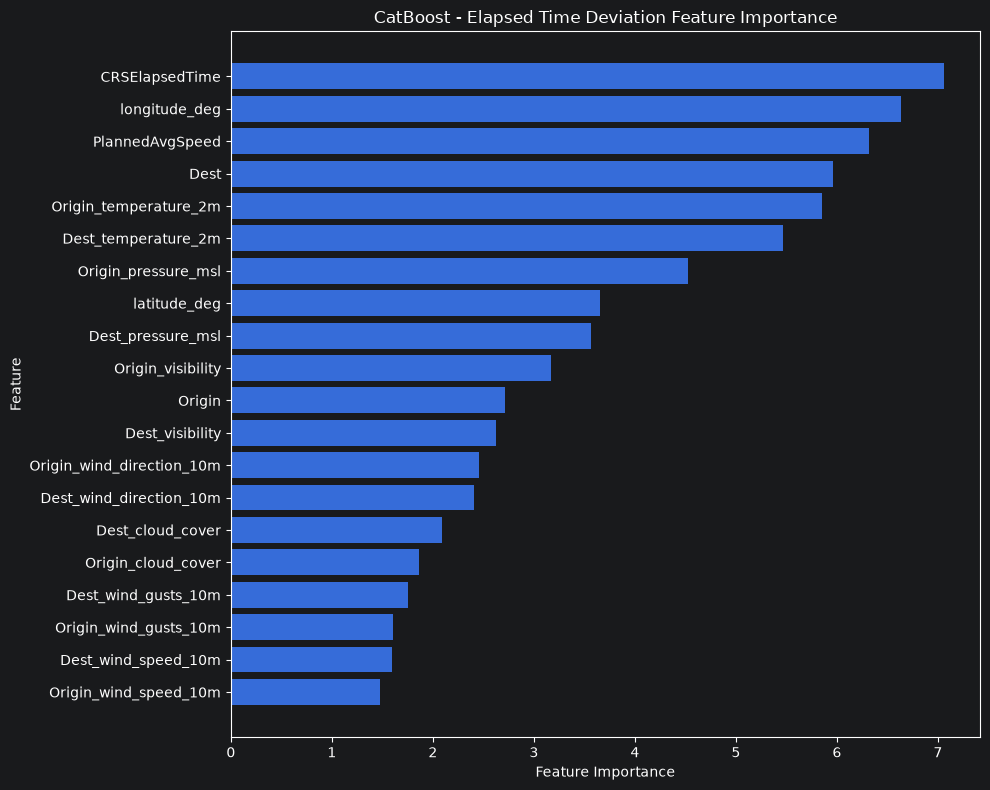

In [223]:
plt.figure(figsize=(10, 8))

plt.barh(
    cat_importance_df.head(20)["Feature"][::-1],
    cat_importance_df.head(20)["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("CatBoost - Elapsed Time Deviation Feature Importance")

plt.tight_layout()
plt.show()

### Elapsed Time Deviation - Feature Importance Findings

CatBoost feature importance sonuçlarında planlanan uçuş süresi (`CRSElapsedTime`), coğrafi konum, planlanan ortalama hız ve destination havalimanı en etkili değişkenler arasında yer almaktadır.

Origin ve Destination hava durumu değişkenlerinin önemli bir kısmının ilk 20 feature içerisinde bulunması, uçuş süresi sapmasının meteorolojik koşullardan etkilendiğini göstermektedir. Özellikle sıcaklık, basınç, görüş mesafesi ve rüzgâr değişkenleri model kararlarında önemli rol oynamıştır.

Destination weather değişkenlerinin üst sıralarda yer alması, modele Destination T-60 hava durumu eklenmesinin faydalı bir feature engineering adımı olduğunu desteklemektedir.

Feature importance değerleri değişkenlerin model tahminindeki göreli önemini göstermektedir; doğrudan nedensellik olarak yorumlanmamalıdır.

In [224]:
from sklearn.inspection import permutation_importance

X_val_sample = X_Val.sample(
    n=10000,
    random_state=11
)

y_dep_val_sample = y_dep_val.loc[X_val_sample.index]

In [225]:
perm_importance_m1 = permutation_importance(
    hist_dep_weather_model,
    X_val_sample,
    y_dep_val_sample,
    scoring="neg_mean_absolute_error",
    n_repeats=2,
    random_state=11,
    n_jobs=-1
)

In [226]:
m1_importance_df = pd.DataFrame({
    "Feature": X_Val.columns,
    "Importance": perm_importance_m1.importances_mean
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

m1_importance_df.head(20)

,Feature,Importance
0,ArrivalTimePeriod_Morning,0.725514
1,ArrivalTimePeriod_Evening,0.511974
2,Origin_visibility,0.418569
3,Dest_visibility,0.282128
4,DepartureTimePeriod_Morning,0.223975
5,longitude_deg,0.192199
6,Origin_temperature_2m,0.144902
7,ArrivalTimePeriod_Afternoon,0.136486
8,Dest_temperature_2m,0.128206
9,Origin,0.110124


### Departure Delay - Feature Importance Findings

Permutation Importance analizinde kalkış gecikmesi (`DepDelay`) tahmininde uçuşun gün içindeki zaman dilimini temsil eden değişkenlerin öne çıktığı görülmüştür.

Özellikle `ArrivalTimePeriod_Morning`, `ArrivalTimePeriod_Evening` ve `DepartureTimePeriod_Morning` değişkenleri model performansında önemli rol oynamıştır.

Meteorolojik değişkenler arasında Origin ve Destination görüş mesafesi ile sıcaklık değişkenleri üst sıralarda yer almaktadır. Ayrıca kalkış havalimanının coğrafi konumu ve Origin bilgisi de model tahminlerine katkı sağlamaktadır.

Bu sonuçlar, kalkış gecikmelerinin zamanlama, hava durumu ve havalimanı özelliklerinin birlikte oluşturduğu bir yapıdan etkilendiğini göstermektedir.

Permutation Importance sonuçları değişkenlerin tahmin performansına katkısını göstermektedir; nedensellik olarak yorumlanmamalıdır.

In [228]:
xgb_importance_df = pd.DataFrame({
    "Feature": X_Train.columns,
    "Importance": xgb_arr_weather_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

xgb_importance_df.head(20)

,Feature,Importance
0,ArrivalTimePeriod_Evening,0.071228
1,ArrivalTimePeriod_Morning,0.038577
2,Month_7,0.032558
3,DepartureTimePeriod_Morning,0.029762
4,Season_Summer,0.026184
5,ArrivalHour_15,0.016693
6,DayOfWeek_7,0.016153
7,Origin_snowfall,0.015534
8,DepartureHour_14,0.014158
9,Reporting_Airline_MQ,0.013009


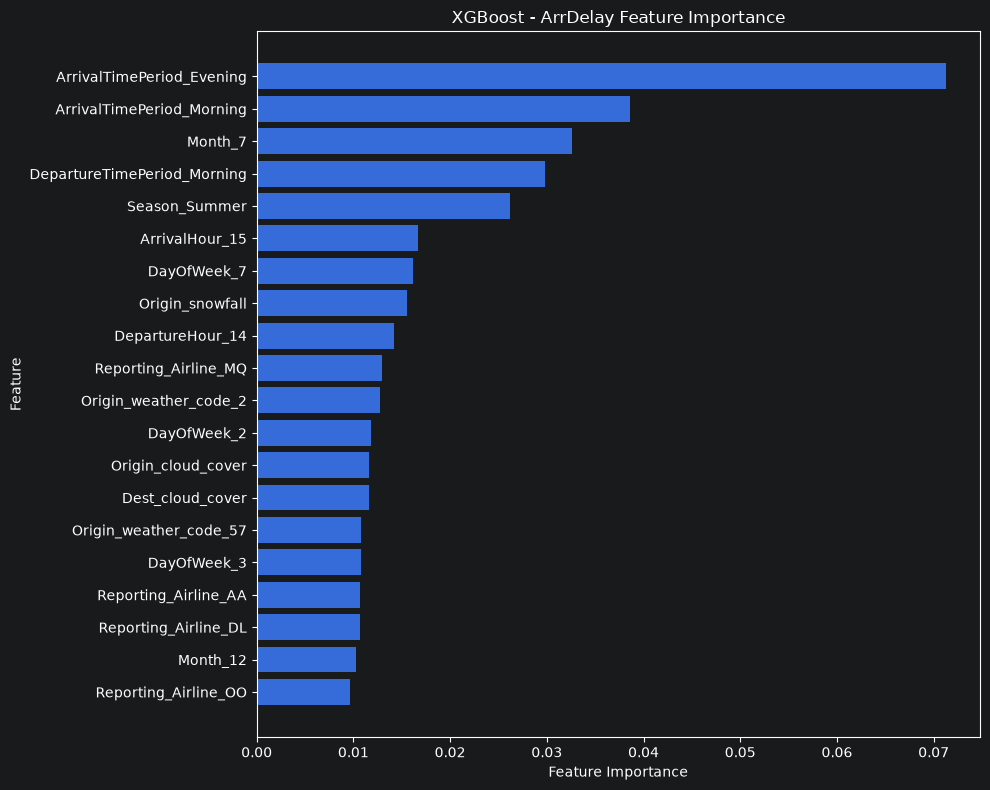

In [229]:
plt.figure(figsize=(10, 8))

plt.barh(
    xgb_importance_df.head(20)["Feature"][::-1],
    xgb_importance_df.head(20)["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost - ArrDelay Feature Importance")

plt.tight_layout()
plt.show()

### Arrival Delay - Feature Importance Findings

XGBoost feature importance sonuçlarında doğrudan `ArrDelay` tahmininde zamanlama ve takvim değişkenlerinin öne çıktığı görülmüştür.

Özellikle `ArrivalTimePeriod_Evening` en yüksek öneme sahip feature olurken; sabah zaman dilimleri, belirli kalkış/varış saatleri, Temmuz ayı ve yaz sezonu da önemli değişkenler arasında yer almıştır.

Havayolu şirketine ait bazı kategorilerin ve gün-of-week değişkenlerinin de modele katkı sağladığı görülmektedir.

Meteorolojik değişkenler tamamen etkisiz değildir. Origin snowfall, weather code ve Origin/Destination cloud cover değişkenleri ilk önemli feature'lar arasında yer almıştır.

M2 modelinde uçuş planı ve hava durumu değişkenleri daha belirgin biçimde öne çıkarken, doğrudan ArrDelay modelinde zamanlama ve takvim değişkenlerinin daha baskın olması, component modellerin gecikmenin farklı yapılarını ayrı ayrı öğrenebildiğini düşündürmektedir.

Feature importance değerleri modelin tahminlerinde kullandığı ilişkileri göstermektedir ve nedensellik olarak yorumlanmamalıdır.

## Saving Final Artifacts

Final modeller, preprocessing nesneleri ve sonuç tabloları tekrar kullanılmak üzere proje klasörlerine kaydedilebilir.


In [ ]:
Path("../models").mkdir(parents=True, exist_ok=True)
Path("../reports").mkdir(parents=True, exist_ok=True)

joblib.dump(hist_dep_weather_model, "../models/m1_depdelay_histgradientboosting.pkl")
joblib.dump(cat_elapsed_final, "../models/m2_elapsed_catboost.pkl")
joblib.dump(xgb_arr_weather_model, "../models/m3_arrdelay_xgboost.pkl")
joblib.dump(freq_encoder, "../models/frequency_encoder.pkl")
joblib.dump(ohe_encoder, "../models/ohe_encoder.pkl")
joblib.dump(scaler, "../models/standard_scaler.pkl")

final_results_df.to_csv("../reports/final_test_results.csv", index=False)
blend_df.to_csv("../reports/validation_blend_results.csv", index=False)


# Final Conclusion

Final holdout testte üç yaklaşım karşılaştırılmıştır:

| Approach | MAE | RMSE | R² |
|---|---:|---:|---:|
| Direct (M3) | 29.69 | 62.83 | 0.0508 |
| Component (M1 + M2) | **29.23** | 62.39 | 0.0640 |
| Ensemble (75% Component + 25% Direct) | 29.24 | **62.35** | **0.0652** |

**Ana bulgu:** Varış gecikmesini operasyonel bileşenlerine ayırmak, doğrudan `ArrDelay` tahmininden daha başarılı olmuştur. Component model en düşük MAE değerini verirken, validation döneminde seçilen %75 Component + %25 Direct ensemble en düşük RMSE ve en yüksek R² değerine ulaşmıştır.

Bununla birlikte R² değerlerinin düşük kalması, T-60 anında kullanılan schedule ve hava durumu bilgilerinin gecikmenin tüm değişkenliğini açıklamak için yeterli olmadığını göstermektedir. Sonuçlar bu sınır açıkça belirtilerek yorumlanmalıdır.
